Step 1: Load the Data
The dataset contains space-separated values. We use pandas read_csv with sep='\s+' to handle the varying spaces between numbers.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Define the column names (26 columns total)
# Based on the readme file structure
index_names = ['unit_number', 'time_cycles']
setting_names = ['setting_1', 'setting_2', 'setting_3']
sensor_names = [f'sensor_{i}' for i in range(1, 22)]
col_names = index_names + setting_names + sensor_names

# 2. Load the datasets
# We use sep=r'\s+' because the data is separated by spaces, not commas
train = pd.read_csv('train_FD004.txt', sep=r'\s+', header=None, names=col_names)
test = pd.read_csv('test_FD004.txt', sep=r'\s+', header=None, names=col_names)
y_test = pd.read_csv('RUL_FD004.txt', sep=r'\s+', header=None, names=['RUL'])

print(f"Train Shape: {train.shape}")
print(f"Test Shape: {test.shape}")
print("First 5 rows of the dataframe:")
display(train.head())  # 'display()' makes it look nicer in Colab than 'print()'

print("\nDataframe Shape (Rows, Columns):")
print(train.shape)

print("\nData Info (Column types and Null values):")
print(train.info())

print("Not null check train" ,train.notnull().any().any())
print("Not null check test" ,test.notnull().any().any())
print("Not null check y_test " ,y_test.notnull().any().any())


display(test.head())  # 'display()' makes it look nicer in Colab than 'print()'
display(y_test.head())  # 'display()' makes it look nicer in Colab than 'print()'



Train Shape: (61249, 26)
Test Shape: (41214, 26)
First 5 rows of the dataframe:


,unit_number,time_cycles,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,42.0049,0.8400,100.0,445.00,549.68,1343.43,1112.93,3.91,...,129.78,2387.99,8074.83,9.3335,0.02,330,2212,100.00,10.62,6.3670
1,1,2,20.0020,0.7002,100.0,491.19,606.07,1477.61,1237.50,9.35,...,312.59,2387.73,8046.13,9.1913,0.02,361,2324,100.00,24.37,14.6552
2,1,3,42.0038,0.8409,100.0,445.00,548.95,1343.12,1117.05,3.91,...,129.62,2387.97,8066.62,9.4007,0.02,329,2212,100.00,10.48,6.4213
3,1,4,42.0000,0.8400,100.0,445.00,548.70,1341.24,1118.03,3.91,...,129.80,2388.02,8076.05,9.3369,0.02,328,2212,100.00,10.54,6.4176
4,1,5,25.0063,0.6207,60.0,462.54,536.10,1255.23,1033.59,7.05,...,164.11,2028.08,7865.80,10.8366,0.02,305,1915,84.93,14.03,8.6754



Dataframe Shape (Rows, Columns):
(61249, 26)

Data Info (Column types and Null values):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61249 entries, 0 to 61248
Data columns (total 26 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   unit_number  61249 non-null  int64  
 1   time_cycles  61249 non-null  int64  
 2   setting_1    61249 non-null  float64
 3   setting_2    61249 non-null  float64
 4   setting_3    61249 non-null  float64
 5   sensor_1     61249 non-null  float64
 6   sensor_2     61249 non-null  float64
 7   sensor_3     61249 non-null  float64
 8   sensor_4     61249 non-null  float64
 9   sensor_5     61249 non-null  float64
 10  sensor_6     61249 non-null  float64
 11  sensor_7     61249 non-null  float64
 12  sensor_8     61249 non-null  float64
 13  sensor_9     61249 non-null  float64
 14  sensor_10    61249 non-null  float64
 15  sensor_11    61249 non-null  float64
 16  sensor_12    61249 non-null  float64
 17 

,unit_number,time_cycles,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,20.0072,0.7000,100.0,491.19,606.67,1481.04,1227.81,9.35,...,313.03,2387.78,8048.98,9.2229,0.02,362,2324,100.00,24.31,14.7007
1,1,2,24.9984,0.6200,60.0,462.54,536.22,1256.17,1031.48,7.05,...,163.61,2028.09,7863.46,10.8632,0.02,306,1915,84.93,14.36,8.5748
2,1,3,42.0000,0.8420,100.0,445.00,549.23,1340.13,1105.88,3.91,...,129.98,2387.95,8071.13,9.3960,0.02,328,2212,100.00,10.39,6.4365
3,1,4,42.0035,0.8402,100.0,445.00,549.19,1339.70,1107.26,3.91,...,129.48,2387.90,8078.89,9.3594,0.02,328,2212,100.00,10.56,6.2367
4,1,5,35.0079,0.8400,100.0,449.44,555.10,1353.04,1117.80,5.48,...,181.82,2387.87,8057.83,9.3030,0.02,333,2223,100.00,14.85,8.9326


,RUL
0,22
1,39
2,107
3,75
4,149


**Step 2: Identify "Noisy" Data & Feature Selection
To identify "noisy" or useless data, you should look for columns that do not change (constant values). If a sensor always outputs the same number (e.g., "100.0"), it provides no information to the model and should be discarded.**

In [ ]:
# 3. Identify and Drop Constant Columns (Noise/Useless)
# Check standard deviation. If std == 0, the column is constant.
def drop_constant_columns(df):
    # Get columns where standard deviation is 0
    # con_cols = [col for col in df.columns if df[col].std() == 0]
    con_cols = [col for col in train.columns if train[col].nunique() == 1]
    print(f"Dropping constant columns: {con_cols}")
    return df.drop(columns=con_cols)

train_clean = drop_constant_columns(train)
test_clean = test[train_clean.columns] # Apply same drop to test set

# 4. Feature Selection
# The columns you should use for training are the remaining sensors and settings
features = [col for col in train_clean.columns if col not in ['unit_number', 'time_cycles', 'RUL']]
print(f"\nFeatures to use for training: {features}")

Dropping constant columns: []

Features to use for training: ['setting_1', 'setting_2', 'setting_3', 'sensor_1', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_5', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_10', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_16', 'sensor_17', 'sensor_18', 'sensor_19', 'sensor_20', 'sensor_21']


In [ ]:
print(f"Standard deviation of sensor_5 in original train data: {train['setting_3'].std()}")
print(f"Standard deviation of sensor_10 in original train data: {train['sensor_18'].std()}")
print(f"Standard deviation of sensor_16 in original train data: {train['sensor_19'].std()}")

Standard deviation of sensor_5 in original train data: 14.251953918804812
Standard deviation of sensor_10 in original train data: 145.47249119147062
Standard deviation of sensor_16 in original train data: 5.369423638907298


In [ ]:
import pandas as pd

# 1. Load the Raw Test Data (Sensor History)
test_df = pd.read_csv('test_FD004.txt', sep=r'\s+', header=None, names=col_names)

# 2. Load the True RUL (Answer Key)
y_true = pd.read_csv('RUL_FD004.txt', sep=r'\s+', header=None, names=['RUL'])

# 3. Process Test Data: Get the LAST row for each engine
# We only predict RUL at the end of the observed sequence
X_test = test_df.groupby('unit_number').last().reset_index()

# 4. Map the True RUL to the Feature Matrix
# The RUL file is in order (Row 0 is Engine 1, Row 1 is Engine 2, etc.)
# We just add it as a new column
X_test['RUL'] = y_true['RUL']

# 5. Apply the same "Clipping" to Test RUL (Crucial for fair evaluation)
# If you trained your model to never predict > 125, you should also clip the test set to 125
X_test['RUL'] = X_test['RUL'].clip(upper=125)

# Removed: Dropping columns from X_test, as the training set did not drop these features.
# This ensures X_test contains all features the model was trained on.


# Final Check
print(f"Final Test Shape: {X_test.shape}")
print(X_test.head())
display(X_test.head())

Final Test Shape: (248, 27)
   unit_number  time_cycles  setting_1  setting_2  setting_3  sensor_1  \
0            1          230    25.0070     0.6214       60.0    462.54   
1            2          153    41.9989     0.8400      100.0    445.00   
2            3          141    42.0005     0.8401      100.0    445.00   
3            4          208    25.0018     0.6207       60.0    462.54   
4            5           51    25.0039     0.6200       60.0    462.54   

   sensor_2  sensor_3  sensor_4  sensor_5  ...  sensor_13  sensor_14  \
0    537.66   1264.31   1046.41      7.05  ...    2028.53    7890.31   
1    549.96   1354.05   1133.55      3.91  ...    2387.72    8073.44   
2    549.47   1341.06   1118.90      3.91  ...    2388.18    8095.58   
3    536.06   1253.49   1038.53      7.05  ...    2028.30    7878.63   
4    537.36   1263.60   1052.52      7.05  ...    2028.24    7873.75   

   sensor_15  sensor_16  sensor_17  sensor_18  sensor_19  sensor_20  \
0    10.7615       0.02

,unit_number,time_cycles,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,RUL
0,1,230,25.0070,0.6214,60.0,462.54,537.66,1264.31,1046.41,7.05,...,2028.53,7890.31,10.7615,0.02,308,1915,84.93,14.41,8.6329,22
1,2,153,41.9989,0.8400,100.0,445.00,549.96,1354.05,1133.55,3.91,...,2387.72,8073.44,9.3925,0.02,331,2212,100.00,10.58,6.4325,39
2,3,141,42.0005,0.8401,100.0,445.00,549.47,1341.06,1118.90,3.91,...,2388.18,8095.58,9.2974,0.02,330,2212,100.00,10.61,6.3488,107
3,4,208,25.0018,0.6207,60.0,462.54,536.06,1253.49,1038.53,7.05,...,2028.30,7878.63,10.8396,0.02,306,1915,84.93,14.41,8.5696,75
4,5,51,25.0039,0.6200,60.0,462.54,537.36,1263.60,1052.52,7.05,...,2028.24,7873.75,10.9094,0.02,307,1915,84.93,14.19,8.6248,125


In [ ]:
# 5. Calculate RUL for Training Data
# RUL is defined as the number of remaining operational cycles until failure.
# For each unit, this is the max_time_cycle - current_time_cycle.
max_cycles = train_clean.groupby('unit_number')['time_cycles'].max()
train_clean = train_clean.merge(max_cycles.rename('max_cycle'), left_on='unit_number', right_index=True)
train_clean['RUL'] = train_clean['max_cycle'] - train_clean['time_cycles']

# 6. Clip RUL at 125 for Training Data (Common Practice for this Dataset)
# This prevents the model from overpredicting RUL early in the engine's life.
train_clean['RUL'] = train_clean['RUL'].clip(upper=125)

print("First 5 rows of training data with RUL:")
display(train_clean.head())

print("Last 5 rows of training data with RUL (should show low RUL values):")
display(train_clean.tail())

First 5 rows of training data with RUL:


,unit_number,time_cycles,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,max_cycle,RUL
0,1,1,42.0049,0.8400,100.0,445.00,549.68,1343.43,1112.93,3.91,...,8074.83,9.3335,0.02,330,2212,100.00,10.62,6.3670,321,125
1,1,2,20.0020,0.7002,100.0,491.19,606.07,1477.61,1237.50,9.35,...,8046.13,9.1913,0.02,361,2324,100.00,24.37,14.6552,321,125
2,1,3,42.0038,0.8409,100.0,445.00,548.95,1343.12,1117.05,3.91,...,8066.62,9.4007,0.02,329,2212,100.00,10.48,6.4213,321,125
3,1,4,42.0000,0.8400,100.0,445.00,548.70,1341.24,1118.03,3.91,...,8076.05,9.3369,0.02,328,2212,100.00,10.54,6.4176,321,125
4,1,5,25.0063,0.6207,60.0,462.54,536.10,1255.23,1033.59,7.05,...,7865.80,10.8366,0.02,305,1915,84.93,14.03,8.6754,321,125


Last 5 rows of training data with RUL (should show low RUL values):


,unit_number,time_cycles,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,max_cycle,RUL
61244,249,251,9.9998,0.2500,100.0,489.05,605.33,1516.36,1315.28,10.52,...,8185.69,8.4541,0.03,372,2319,100.0,29.11,17.5234,255,4
61245,249,252,0.0028,0.0015,100.0,518.67,643.42,1598.92,1426.77,14.62,...,8185.47,8.2221,0.03,396,2388,100.0,39.38,23.7151,255,3
61246,249,253,0.0029,0.0000,100.0,518.67,643.68,1607.72,1430.56,14.62,...,8193.94,8.2525,0.03,395,2388,100.0,39.78,23.8270,255,2
61247,249,254,35.0046,0.8400,100.0,449.44,555.77,1381.29,1148.18,5.48,...,8125.64,9.0515,0.02,337,2223,100.0,15.26,9.0774,255,1
61248,249,255,42.0030,0.8400,100.0,445.00,549.85,1369.75,1147.45,3.91,...,8144.33,9.1207,0.02,333,2212,100.0,10.66,6.4341,255,0


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import numpy as np

# 1. Define Features (X) and Target (y)
# Drop non-feature columns. We use the 'RUL' column (which is now clipped) as target.
features = [col for col in train_clean.columns
            if col not in ['unit_number', 'time_cycles', 'max_cycle', 'RUL']]

X_train = train_clean[features]
y_train = train_clean['RUL']

print(f"Features used for training: {features}")

# 2. Initialize and Train the Model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

print("Linear Regression Model Trained Successfully!")

# 3. Quick Sanity Check (Evaluate on Training Data)
# Ideally, RMSE should be around 20-22 for this dataset
predictions = lr_model.predict(X_train)
mse = mean_squared_error(y_train, predictions)
rmse = np.sqrt(mse)
print(f"Training RMSE: {rmse:.2f}")

Features used for training: ['setting_1', 'setting_2', 'setting_3', 'sensor_1', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_5', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_10', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_16', 'sensor_17', 'sensor_18', 'sensor_19', 'sensor_20', 'sensor_21']
Linear Regression Model Trained Successfully!
Training RMSE: 21.44


Predicted RUL values: [ 48.027767    86.20447694 101.39698562 105.56834692  69.03856643
 101.42677401  84.87402529  23.03583215 105.37608901 120.5617383
 115.9161771    0.46822352  60.56698129  86.83626367  31.06812141
 101.06357173  92.56804823 102.90273135 126.07643672  93.86439864
 108.4441933   11.80952077  62.89216803 100.49929301  41.39765762
  92.87336659  75.37105004 119.41773495 102.60884049 113.39954419
  33.77756487  66.68612304 136.24458688  85.36099311  44.80651212
  95.53961232  67.89576035  76.02037572  93.17363588  13.37985012
  62.27709054  39.40633701 102.53638394  42.32221704 106.16269621
  89.59144014  43.83688187  74.98137864  46.08396683  92.74534177
 140.38413576 139.52807115 127.41371428  83.00441836 109.89975632
 109.17574538 119.21592543  18.88083162 118.13516233 102.80842194
  49.71637403  69.04792292 122.31124496  91.22209093  -8.33093425
  84.32759665  61.9229703   64.41244663  17.75543089  59.47992046
  38.58512273 121.20825314  44.46987099  99.87663838 10

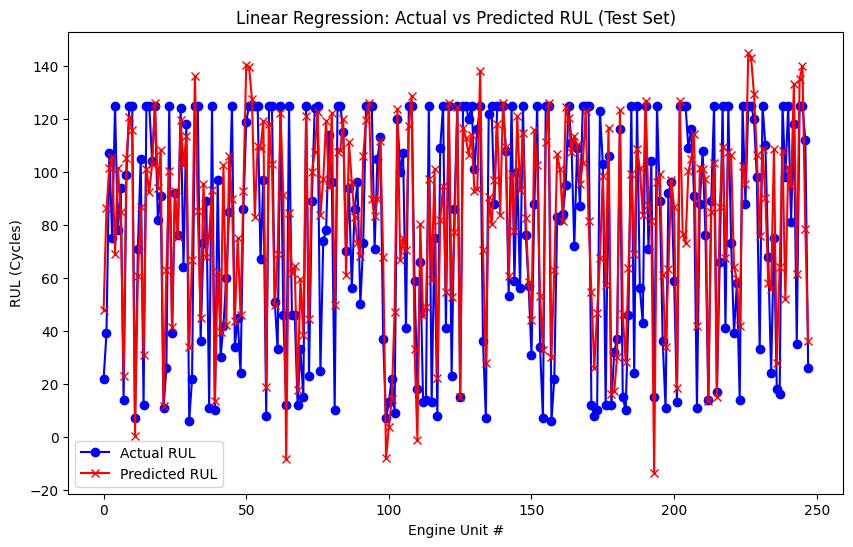

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# 1. Load Test Data
test = pd.read_csv('test_FD004.txt', sep=r'\s+', header=None, names=col_names)
y_true = pd.read_csv('RUL_FD004.txt', sep=r'\s+', header=None, names=['RUL'])

# 2. Prepare Test Data (Group by Unit -> Take Last Row)
# We only predict the RUL at the very end of the observed data
X_test = test.groupby('unit_number').last().reset_index()

# 3. Add the True RUL (The Answer Key)
X_test['RUL'] = y_true['RUL']

# 4. Clip the Test RUL (To match the Training logic)
X_test['RUL_clipped'] = X_test['RUL'].clip(upper=125)

# 5. Select the Same Features as Training
# The 'features' variable is already defined in a previous cell and contains
# the exact columns used for training the linear regression model.
X_test_features = X_test[features]

# 6. Predict
y_pred_test = lr_model.predict(X_test_features)
print("Predicted RUL values:", y_pred_test)


# 7. Evaluate
rmse_test = np.sqrt(mean_squared_error(X_test['RUL_clipped'], y_pred_test))
r2_test = r2_score(X_test['RUL_clipped'], y_pred_test)

print(f"Test RMSE: {rmse_test:.2f}")
print(f"Test R2: {r2_test:.2f}")

# 8. Visualization: Actual vs Predicted
plt.figure(figsize=(10, 6))
plt.plot(X_test['RUL_clipped'], label='Actual RUL', color='blue', marker='o')
plt.plot(y_pred_test, label='Predicted RUL', color='red', marker='x')
plt.title('Linear Regression: Actual vs Predicted RUL (Test Set)')
plt.ylabel('RUL (Cycles)')
plt.xlabel('Engine Unit #')
plt.legend()
plt.show()

Training Random Forest...
predicted RUL for random forest [ 55.94  61.31  91.41 107.88  85.9  118.66 104.45  18.1   74.69 117.93
 122.3    8.18  58.06 110.56  25.55 123.39 116.7   85.9  122.67  94.34
 111.41  15.95  59.82 108.22  50.29 107.67  76.81 119.1   95.8  119.46
   9.95  35.28 124.24  97.    30.95  93.81  55.4   38.65  80.36  12.77
  84.78  22.05 111.61  31.65  98.79 107.69  36.25  70.16  29.45 103.14
 123.06 123.62 119.28  89.8  116.12 121.25 122.11   6.94 117.84 111.75
  36.99  49.23 117.38  42.96  28.34 104.83  66.52  42.05  23.93  48.48
  23.36 123.36  43.03 107.31 110.45 123.03  76.64 106.21 103.54 112.61
 109.04  25.45  97.74 124.75 106.92  48.01 101.73  97.99  69.84  82.8
  48.   122.5  119.32 120.53 102.17  87.71 103.21 123.58  58.56  19.6
  14.12  15.01  13.46 123.5   66.49  57.45  79.64 122.1  122.    63.84
  25.25  84.73  18.83  22.39 117.1   20.04 109.58  25.84  76.21 101.03
  46.76 123.45  31.4   68.83 121.78  15.59 121.89 111.4  114.7  111.69
  98.56 112.72 123.8 

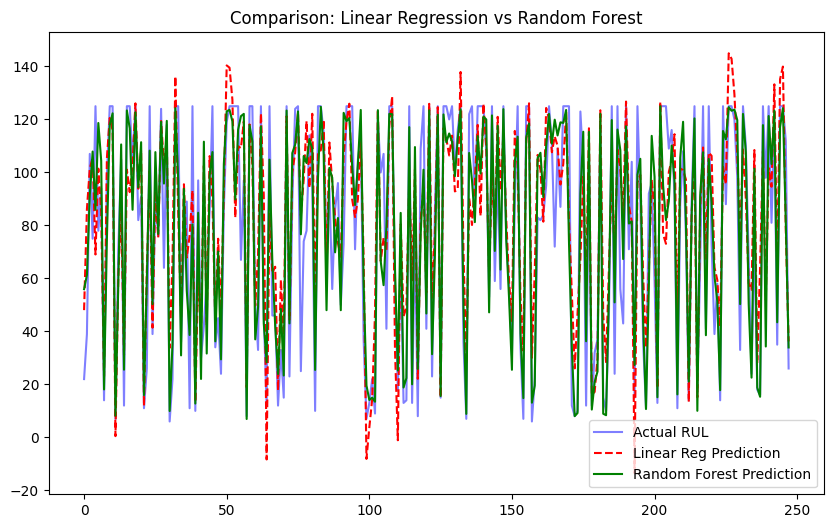

In [ ]:
from sklearn.ensemble import RandomForestRegressor

# 1. Initialize Random Forest
# n_estimators=100 means we use 100 different decision trees
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

# 2. Train the Model
print("Training Random Forest...")
rf_model.fit(X_train, y_train) # specific to your previous variable names

# 3. Predict on Test Data
# X_test_features should now be correctly aligned after the fix in the previous cell
y_pred_rf = rf_model.predict(X_test_features)
print("predicted RUL for random forest", y_pred_rf)

# 4. Evaluate
rmse_rf = np.sqrt(mean_squared_error(X_test['RUL_clipped'], y_pred_rf))
r2_rf = r2_score(X_test['RUL_clipped'], y_pred_rf)

print(f"Random Forest RMSE: {rmse_rf:.2f}")
print(f"Random Forest R2: {r2_rf:.2f}")

# 5. Visualization Comparison
plt.figure(figsize=(10, 6))
plt.plot(X_test['RUL_clipped'], label='Actual RUL', color='blue', alpha=0.5)
plt.plot(y_pred_test, label='Linear Reg Prediction', color='red', linestyle='--')
plt.plot(y_pred_rf, label='Random Forest Prediction', color='green')
plt.title('Comparison: Linear Regression vs Random Forest')
plt.legend()
plt.show()

Training XGBoost...
XGBoost RMSE: 19.09
XGBoost R2: 0.80


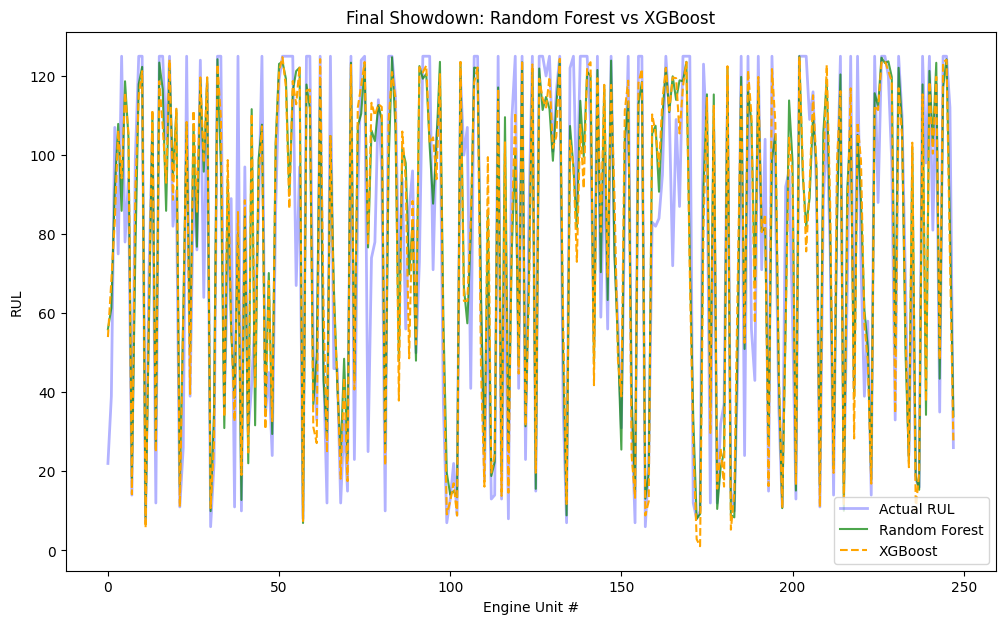


--- FINAL GRU RESULTS ---
RMSE:        19.09
R²:          0.80
PHM Penalty: 40987.03


In [ ]:
from xgboost import XGBRegressor

# 1. Initialize XGBoost
# n_estimators=100: Number of trees
# learning_rate=0.1: How much each tree corrects the errors of the previous one
xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)

# 2. Train
print("Training XGBoost...")
xgb_model.fit(X_train, y_train)

# 3. Predict
# X_test_features should now be correctly aligned after the fix in the previous cell
y_pred_xgb = xgb_model.predict(X_test_features)

# 4. Evaluate
rmse_xgb = np.sqrt(mean_squared_error(X_test['RUL_clipped'], y_pred_xgb))
r2_xgb = r2_score(X_test['RUL_clipped'], y_pred_xgb)

print(f"XGBoost RMSE: {rmse_xgb:.2f}")
print(f"XGBoost R2: {r2_xgb:.2f}")

# 5. Visual Comparison (All 3 models)
plt.figure(figsize=(12, 7))
plt.plot(X_test['RUL_clipped'], label='Actual RUL', color='blue', alpha=0.3, linewidth=2)
plt.plot(y_pred_rf, label='Random Forest', color='green', alpha=0.7)
plt.plot(y_pred_xgb, label='XGBoost', color='orange', linestyle='--')
plt.title('Final Showdown: Random Forest vs XGBoost')
plt.ylabel('RUL')
plt.xlabel('Engine Unit #')
plt.legend()
plt.show()



/tmp/ipykernel_12299/2153893634.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')


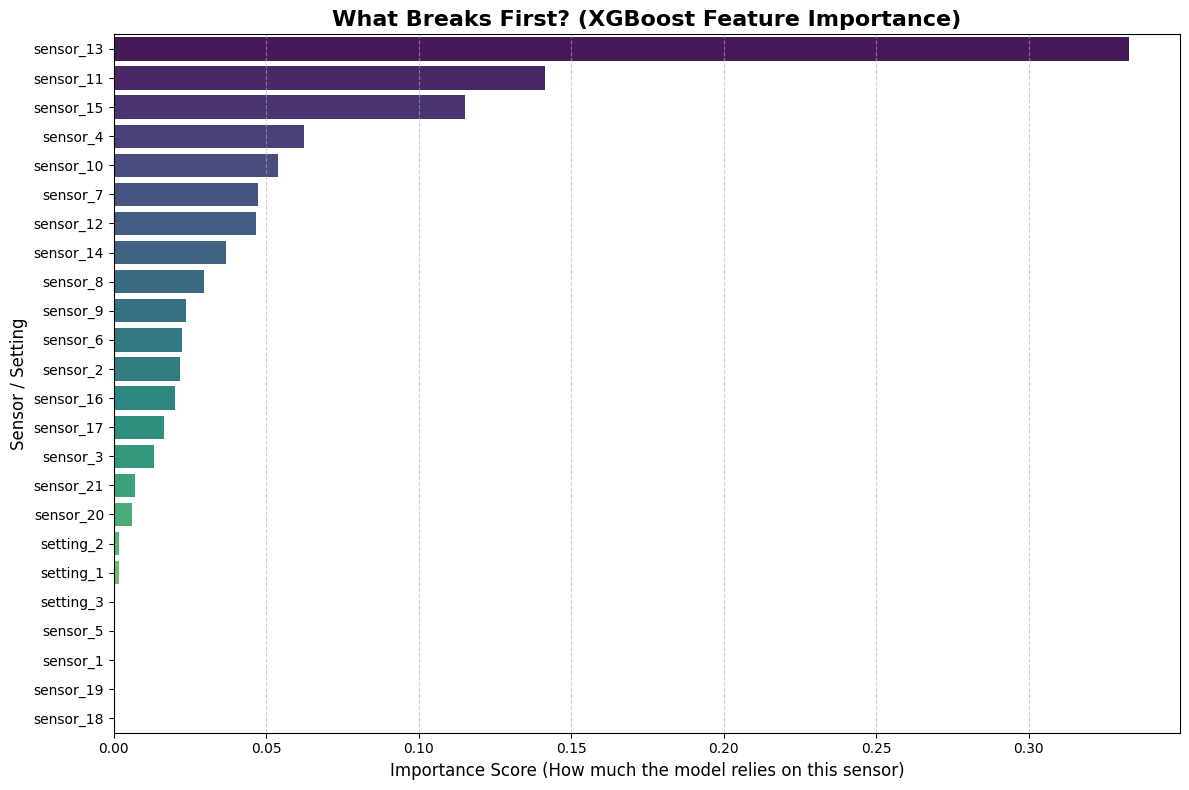

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Extract Feature Importances
# We create a dataframe to map the "Score" to the "Sensor Name"
importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': xgb_model.feature_importances_
})

# 2. Sort the data (Most important at the top)
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# 3. Create the Visualization
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')

# 4. Add Professional Labels
plt.title('What Breaks First? (XGBoost Feature Importance)', fontsize=16, weight='bold')
plt.xlabel('Importance Score (How much the model relies on this sensor)', fontsize=12)
plt.ylabel('Sensor / Setting', fontsize=12)

# 5. Add a grid for readability
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()

# 6. Show the plot
plt.show()



--- Linear Regression ---
RMSE: 24.47
MAE:  19.96
R²:   0.68

--- Random Forest ---
RMSE: 19.16
MAE:  14.06
R²:   0.80

--- XGBoost ---
RMSE: 19.09
MAE:  13.92
R²:   0.80

=== FINAL EVALUATION TABLE (Section 3.3) ===


,RMSE,MAE,R²
Model,,,
XGBoost,19.091837,13.918295,0.802694
Random Forest,19.163303,14.061250,0.801215
Linear Regression,24.471757,19.958166,0.675829


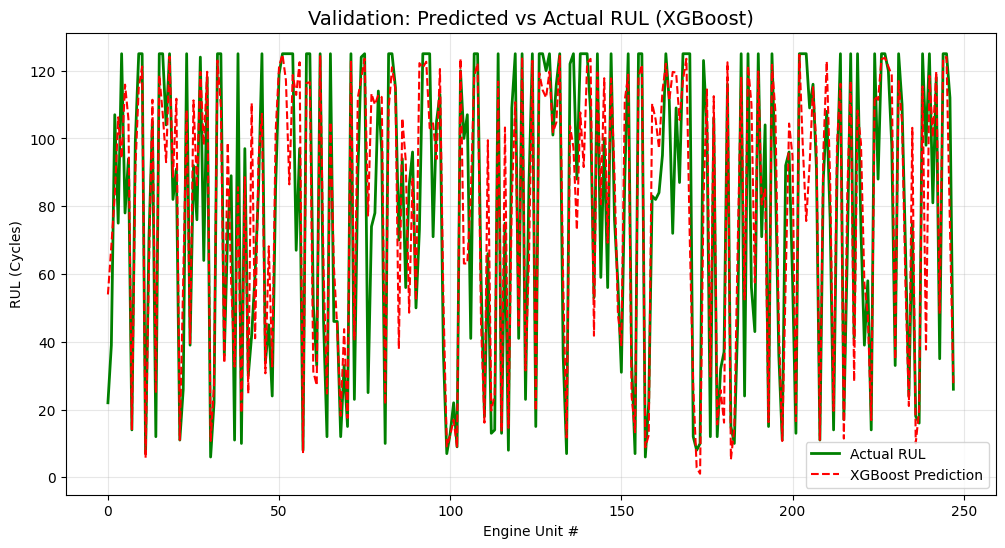


--- FINAL GRU RESULTS ---
RMSE:        19.09
R²:          0.80
PHM Penalty: 40987.03


In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import pandas as pd

# 1. Define an Evaluation Function
def evaluate_model(model, X_test, y_true, model_name):
    # Predict
    y_pred = model.predict(X_test)

    # Calculate Metrics
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    # Print for immediate feedback
    print(f"--- {model_name} ---")
    print(f"RMSE: {rmse:.2f}")
    print(f"MAE:  {mae:.2f}")
    print(f"R²:   {r2:.2f}\n")

    return {'Model': model_name, 'RMSE': rmse, 'MAE': mae, 'R²': r2}

# 2. Run Evaluation on All 3 Models
# (Assumes lr_model, rf_model, and xgb_model are already trained from previous steps)
results = []
results.append(evaluate_model(lr_model, X_test_features, X_test['RUL_clipped'], "Linear Regression"))
results.append(evaluate_model(rf_model, X_test_features, X_test['RUL_clipped'], "Random Forest"))
results.append(evaluate_model(xgb_model, X_test_features, X_test['RUL_clipped'], "XGBoost"))

# 3. Create the Comparison Table
comparison_df = pd.DataFrame(results).set_index('Model')

print("=== FINAL EVALUATION TABLE (Section 3.3) ===")
display(comparison_df.sort_values(by='RMSE'))

# 4. Validation Plot (Actual vs Predicted for Best Model)
# We plot the best model (likely XGBoost) to visually validate performance
plt.figure(figsize=(12, 6))
plt.plot(X_test['RUL_clipped'], label='Actual RUL', color='green', linewidth=2)
plt.plot(xgb_model.predict(X_test_features), label='XGBoost Prediction', color='red', linestyle='--')
plt.title('Validation: Predicted vs Actual RUL (XGBoost)', fontsize=14)
plt.xlabel('Engine Unit #')
plt.ylabel('RUL (Cycles)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
# ==========================================
# 7. CALCULATE PHM PENALTY SCORE
# ==========================================
def calculate_phm_penalty(y_true, y_pred):
    """
    Asymmetric penalty function used in PHM08 / C-MAPSS
    d = predicted_RUL - actual_RUL
    If d < 0 (Early): penalty = exp(-d/13) - 1
    If d >= 0 (Late): penalty = exp(d/10) - 1
    """
    d = y_pred - y_true
    penalty = 0
    for diff in d:
        if diff < 0:
            penalty += np.exp(-diff / 13.0) - 1
        else:
            penalty += np.exp(diff / 10.0) - 1
    return penalty

# Calculate the score
phm_score = calculate_phm_penalty(y_true_valid, pred_cycles)

# Print results including PHM Score
print(f"\n--- FINAL GRU RESULTS ---")
print(f"RMSE:        {rmse_xgb:.2f}")
print(f"R²:          {r2_xgb:.2f}")
print(f"PHM Penalty: {phm_score:.2f}")

<>:24: SyntaxWarning: invalid escape sequence '\s'
<>:25: SyntaxWarning: invalid escape sequence '\s'
<>:26: SyntaxWarning: invalid escape sequence '\s'
<>:24: SyntaxWarning: invalid escape sequence '\s'
<>:25: SyntaxWarning: invalid escape sequence '\s'
<>:26: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_12299/2217470243.py:24: SyntaxWarning: invalid escape sequence '\s'
  train = pd.read_csv('train_FD004.txt', sep='\s+', header=None, names=col_names)
/tmp/ipykernel_12299/2217470243.py:25: SyntaxWarning: invalid escape sequence '\s'
  test = pd.read_csv('test_FD004.txt', sep='\s+', header=None, names=col_names)
/tmp/ipykernel_12299/2217470243.py:26: SyntaxWarning: invalid escape sequence '\s'
  y_true = pd.read_csv('RUL_FD004.txt', sep='\s+', header=None, names=['RUL'])


LSTM Training X Shape: (54028, 30, 24)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
244/244 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - loss: 0.1413 - val_loss: 0.1417
Epoch 2/20
244/244 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0705 - val_loss: 0.0450
Epoch 3/20
244/244 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0508 - val_loss: 0.0498
Epoch 4/20
244/244 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0447 - val_loss: 0.0566
Epoch 5/20
244/244 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0415 - val_loss: 0.0308
Epoch 6/20
244/244 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0352 - val_loss: 0.0271
Epoch 7/20
244/244 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0349 - val_loss: 0.0359
Epoch 8/20
244/244 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0304 - val_loss: 0.0292
Epoch 9/20
244/244 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0312 - val_loss: 0.0222
Epoch 10/20
244/244 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0328 - val_loss: 0.0403
Epoch 11/20
244/244 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0287 - val_loss: 0.0226
Epoch 12/20
244/244 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/ste

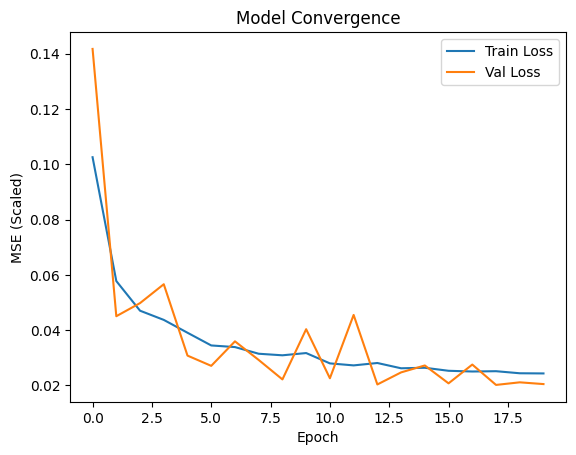

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step

--- FINAL LSTM RESULTS ---
RMSE: 20.25
MAE:  15.62
R²:   0.78


In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt

# ==========================================
# 1. SETUP & CONSTANTS
# ==========================================
SEQUENCE_LENGTH = 30
# Removed: cols_to_drop as no constant columns were dropped in initial processing.

# ==========================================
# 2. LOAD & CLEAN DATA
# ==========================================
index_names = ['unit_number', 'time_cycles']
setting_names = ['setting_1', 'setting_2', 'setting_3']
sensor_names = [f'sensor_{i}' for i in range(1, 22)]
col_names = index_names + setting_names + sensor_names

train = pd.read_csv('train_FD004.txt', sep='\s+', header=None, names=col_names)
test = pd.read_csv('test_FD004.txt', sep='\s+', header=None, names=col_names)
y_true = pd.read_csv('RUL_FD004.txt', sep='\s+', header=None, names=['RUL'])

# Calculate RUL for Train
max_cycles = train.groupby('unit_number')['time_cycles'].transform('max')
train['RUL'] = max_cycles - train['time_cycles']
train['RUL'] = train['RUL'].clip(upper=125)

# Removed: Dropping constant columns, as the initial analysis (pygPWbBF00T9) found none.
# This ensures all sensor and setting features are used consistently.
# test = test.drop(columns=cols_to_drop)

# ==========================================
# 3. SCALING (CRITICAL FIX)
# ==========================================
# A. Scale Features (X) - using all settings and sensors as features
features = [c for c in train.columns if c not in ['unit_number', 'time_cycles', 'RUL']]
scaler_X = MinMaxScaler()
train[features] = scaler_X.fit_transform(train[features])
test[features] = scaler_X.transform(test[features])

# B. Scale Target (y) - THIS FIXES THE CONVERGENCE ISSUE
# We manually divide by 125 since we know that's our max RUL
def scale_rul(rul_series):
    return rul_series / 125.0

train['RUL_scaled'] = scale_rul(train['RUL'])

# ==========================================
# 4. SLIDING WINDOW GENERATOR
# ==========================================
def gen_train_data(id_df, seq_length, seq_cols):
    data_array = id_df[seq_cols].values
    label_array = id_df['RUL_scaled'].values
    num_elements = data_array.shape[0]

    # Check if engine has enough data
    if num_elements < seq_length:
        return np.empty((0, seq_length, len(seq_cols))), np.empty((0,))

    # Create windows
    # Window 0: Cycles 0 to 29 -> Label: RUL at cycle 29
    X_batches = []
    y_batches = []

    for start in range(num_elements - seq_length + 1):
        stop = start + seq_length
        X_batches.append(data_array[start:stop, :])
        y_batches.append(label_array[stop-1]) # Label is the state at the END of the window

    return np.array(X_batches), np.array(y_batches)

# Generate Train Sets
X_train_lstm = []
y_train_lstm = []

for unit_id in train['unit_number'].unique():
    X_temp, y_temp = gen_train_data(train[train['unit_number'] == unit_id], SEQUENCE_LENGTH, features)
    if len(X_temp) > 0:
        X_train_lstm.append(X_temp)
        y_train_lstm.append(y_temp)

X_train_lstm = np.concatenate(X_train_lstm).astype(np.float32)
y_train_lstm = np.concatenate(y_train_lstm).astype(np.float32)

print(f"LSTM Training X Shape: {X_train_lstm.shape}")

# ==========================================
# 5. BUILD & TRAIN MODEL
# ==========================================
model_lstm = Sequential()
model_lstm.add(LSTM(units=128, input_shape=(SEQUENCE_LENGTH, len(features)), return_sequences=True))
model_lstm.add(Dropout(0.3))
model_lstm.add(LSTM(units=64, return_sequences=False))
model_lstm.add(Dropout(0.3))
model_lstm.add(Dense(units=1, activation='linear')) # Output 0 to 1

model_lstm.compile(loss='mean_squared_error', optimizer='adam')

# Train
history = model_lstm.fit(X_train_lstm, y_train_lstm,
                    epochs=20, # Increased epochs
                    batch_size=200,
                    validation_split=0.1,
                    verbose=1)

# Plot Loss to verify convergence
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Convergence')
plt.ylabel('MSE (Scaled)')
plt.xlabel('Epoch')
plt.legend()
plt.show()

# ==========================================
# 6. EVALUATE ON TEST SET
# ==========================================
# Get the last sequence for every test engine
X_test_lstm = []
valid_unit_ids = []

for unit_id in test['unit_number'].unique():
    unit_data = test[test['unit_number'] == unit_id]
    if len(unit_data) >= SEQUENCE_LENGTH:
        # Take the last 'SEQUENCE_LENGTH' rows
        seq = unit_data[features].values[-SEQUENCE_LENGTH:]
        X_test_lstm.append(seq)
        valid_unit_ids.append(unit_id)

X_test_lstm = np.array(X_test_lstm).astype(np.float32)

# Get True RUL for these specific units
y_true_valid = y_true[y_true.index.isin([i-1 for i in valid_unit_ids])]['RUL'].clip(upper=125).values

# Predict
pred_scaled = model_lstm.predict(X_test_lstm)

# Rescale Prediction back to cycles (multiply by 125)
pred_cycles = pred_scaled.flatten() * 125.0

# Calculate Metrics
rmse_lstm = np.sqrt(mean_squared_error(y_true_valid, pred_cycles))
mae = mean_absolute_error(y_true_valid, pred_cycles)
r2 = r2_score(y_true_valid, pred_cycles)

print(f"\n--- FINAL LSTM RESULTS ---")
print(f"RMSE: {rmse_lstm:.2f}")
print(f"MAE:  {mae:.2f}")
print(f"R²:   {r2:.2f}")

<>:25: SyntaxWarning: invalid escape sequence '\s'
<>:26: SyntaxWarning: invalid escape sequence '\s'
<>:27: SyntaxWarning: invalid escape sequence '\s'
<>:25: SyntaxWarning: invalid escape sequence '\s'
<>:26: SyntaxWarning: invalid escape sequence '\s'
<>:27: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_12299/489071327.py:25: SyntaxWarning: invalid escape sequence '\s'
  train = pd.read_csv('train_FD004.txt', sep='\s+', header=None, names=col_names)
/tmp/ipykernel_12299/489071327.py:26: SyntaxWarning: invalid escape sequence '\s'
  test = pd.read_csv('test_FD004.txt', sep='\s+', header=None, names=col_names)
/tmp/ipykernel_12299/489071327.py:27: SyntaxWarning: invalid escape sequence '\s'
  y_true = pd.read_csv('RUL_FD004.txt', sep='\s+', header=None, names=['RUL'])


GRU Training X Shape: (54028, 30, 24)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
244/244 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.1297 - val_loss: 0.0552
Epoch 2/20
244/244 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0532 - val_loss: 0.0394
Epoch 3/20
244/244 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0457 - val_loss: 0.0659
Epoch 4/20
244/244 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0470 - val_loss: 0.0803
Epoch 5/20
244/244 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0489 - val_loss: 0.0518
Epoch 6/20
244/244 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0400 - val_loss: 0.0921
Epoch 7/20
244/244 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0408 - val_loss: 0.0362
Epoch 8/20
244/244 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0348 - val_loss: 0.0340
Epoch 9/20
244/244 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0313 - val_loss: 0.0222
Epoch 10/20
244/244 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0302 - val_loss: 0.0367
Epoch 11/20
244/244 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0304 - val_loss: 0.0219
Epoch 12/20
244/244 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step

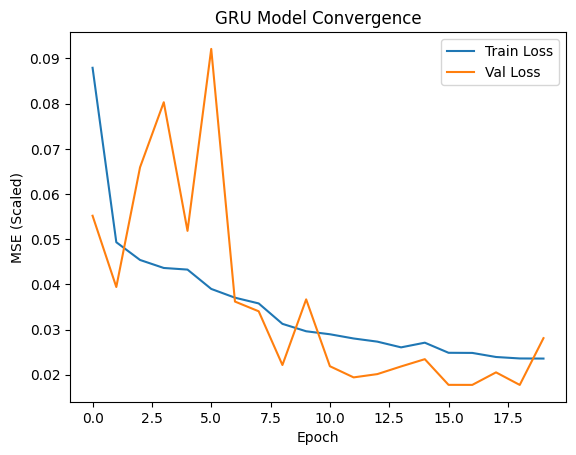

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step

--- FINAL GRU RESULTS ---
RMSE: 26.51
MAE:  19.21
R²:   0.62


In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout  # Changed LSTM to GRU
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt

# ==========================================
# 1. SETUP & CONSTANTS
# ==========================================
SEQUENCE_LENGTH = 30
# Removed: cols_to_drop as no constant columns were dropped in initial processing.

# ==========================================
# 2. LOAD & CLEAN DATA
# ==========================================
index_names = ['unit_number', 'time_cycles']
setting_names = ['setting_1', 'setting_2', 'setting_3']
sensor_names = [f'sensor_{i}' for i in range(1, 22)]
col_names = index_names + setting_names + sensor_names

# Ensure these files are in your working directory
train = pd.read_csv('train_FD004.txt', sep='\s+', header=None, names=col_names)
test = pd.read_csv('test_FD004.txt', sep='\s+', header=None, names=col_names)
y_true = pd.read_csv('RUL_FD004.txt', sep='\s+', header=None, names=['RUL'])

# Calculate RUL for Train
max_cycles = train.groupby('unit_number')['time_cycles'].transform('max')
train['RUL'] = max_cycles - train['time_cycles']
train['RUL'] = train['RUL'].clip(upper=125)

# Removed: Dropping constant columns, as the initial analysis (pygPWbBF00T9) found none.
# This ensures all sensor and setting features are used consistently.
# test = test.drop(columns=cols_to_drop)

# ==========================================
# 3. SCALING
# ==========================================
# A. Scale Features (X) - using all settings and sensors as features
features = [c for c in train.columns if c not in ['unit_number', 'time_cycles', 'RUL']]
scaler_X = MinMaxScaler()
train[features] = scaler_X.fit_transform(train[features])
test[features] = scaler_X.transform(test[features])

# B. Scale Target (y)
def scale_rul(rul_series):
    return rul_series / 125.0

train['RUL_scaled'] = scale_rul(train['RUL'])

# ==========================================
# 4. SLIDING WINDOW GENERATOR
# ==========================================
def gen_train_data(id_df, seq_length, seq_cols):
    data_array = id_df[seq_cols].values
    label_array = id_df['RUL_scaled'].values
    num_elements = data_array.shape[0]

    if num_elements < seq_length:
        return np.empty((0, seq_length, len(seq_cols))), np.empty((0,))

    X_batches = []
    y_batches = []

    for start in range(num_elements - seq_length + 1):
        stop = start + seq_length
        X_batches.append(data_array[start:stop, :])
        y_batches.append(label_array[stop-1])

    return np.array(X_batches), np.array(y_batches)

# Generate Train Sets (Renamed to _gru for clarity)
X_train_gru = []
y_train_gru = []

for unit_id in train['unit_number'].unique():
    X_temp, y_temp = gen_train_data(train[train['unit_number'] == unit_id], SEQUENCE_LENGTH, features)
    if len(X_temp) > 0:
        X_train_gru.append(X_temp)
        y_train_gru.append(y_temp)

X_train_gru = np.concatenate(X_train_gru).astype(np.float32)
y_train_gru = np.concatenate(y_train_gru).astype(np.float32)

print(f"GRU Training X Shape: {X_train_gru.shape}")

# ==========================================
# 5. BUILD & TRAIN MODEL (GRU)
# ==========================================
model_gru = Sequential()

# LAYER 1: GRU (Replaces LSTM)
# units=128 (Same as previous)
# return_sequences=True (Required for stacking RNN layers)
model_gru.add(GRU(units=128, input_shape=(SEQUENCE_LENGTH, len(features)), return_sequences=True))
model_gru.add(Dropout(0.3))

# LAYER 2: GRU (Replaces LSTM)
# units=64 (Same as previous)
# return_sequences=False (Last RNN layer feeds into Dense)
model_gru.add(GRU(units=64, return_sequences=False))
model_gru.add(Dropout(0.3))

# Output Layer
model_gru.add(Dense(units=1, activation='linear'))

model_gru.compile(loss='mean_squared_error', optimizer='adam')

# Train
history = model_gru.fit(X_train_gru, y_train_gru,
                    epochs=20,
                    batch_size=200,
                    validation_split=0.1,
                    verbose=1)

# Plot Loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('GRU Model Convergence')
plt.ylabel('MSE (Scaled)')
plt.xlabel('Epoch')
plt.legend()
plt.show()

# ==========================================
# 6. EVALUATE ON TEST SET
# ==========================================
X_test_gru = []
valid_unit_ids = []

for unit_id in test['unit_number'].unique():
    unit_data = test[test['unit_number'] == unit_id]
    if len(unit_data) >= SEQUENCE_LENGTH:
        seq = unit_data[features].values[-SEQUENCE_LENGTH:]
        X_test_gru.append(seq)
        valid_unit_ids.append(unit_id)

X_test_gru = np.array(X_test_gru).astype(np.float32)

# Get True RUL
y_true_valid = y_true[y_true.index.isin([i-1 for i in valid_unit_ids])]['RUL'].clip(upper=125).values

# Predict
pred_scaled = model_gru.predict(X_test_gru)

# Rescale Prediction back to cycles
pred_cycles = pred_scaled.flatten() * 125.0

# Calculate Metrics
rmse_gru = np.sqrt(mean_squared_error(y_true_valid, pred_cycles))
mae = mean_absolute_error(y_true_valid, pred_cycles)
r2 = r2_score(y_true_valid, pred_cycles)

print(f"\n--- FINAL GRU RESULTS ---")
print(f"RMSE: {rmse_gru:.2f}")
print(f"MAE:  {mae:.2f}")
print(f"R²:   {r2:.2f}")

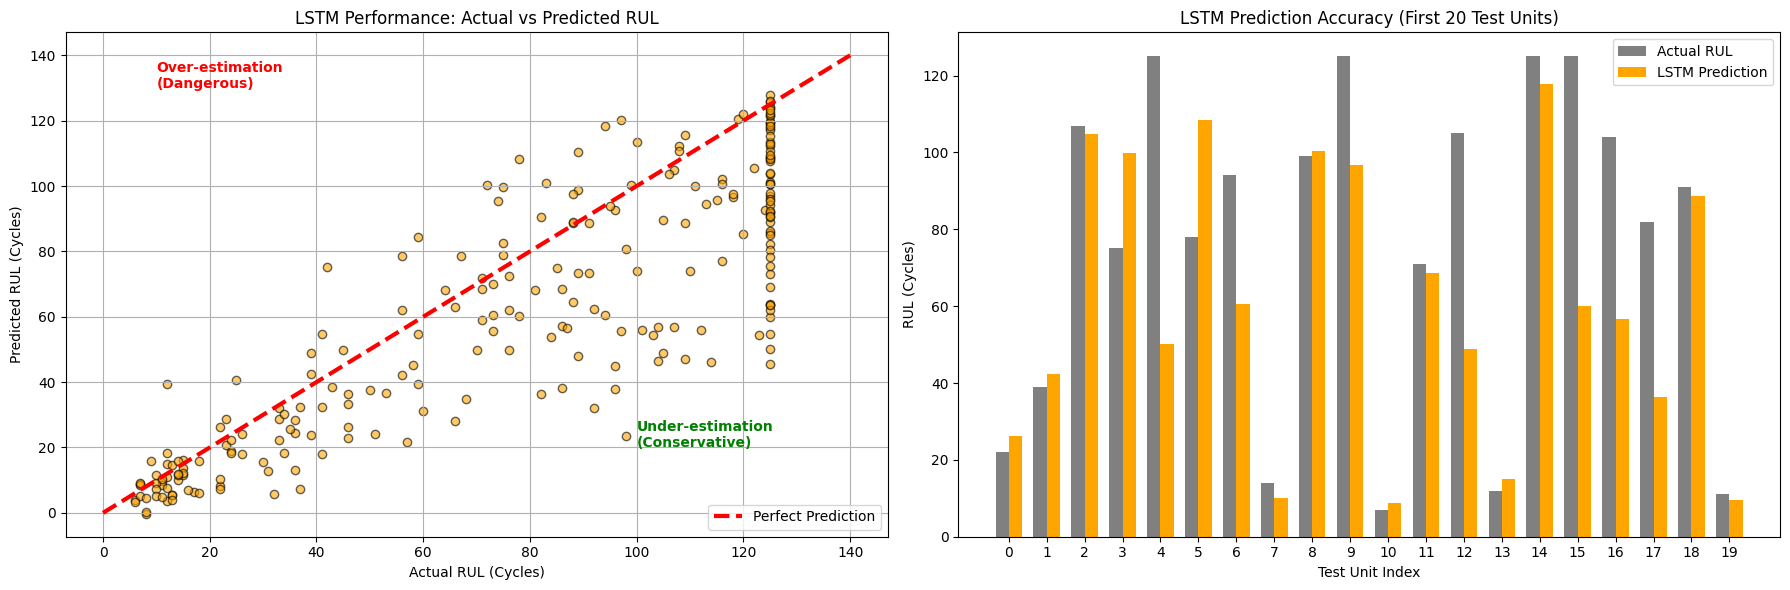

In [ ]:
import matplotlib.pyplot as plt

# ==========================================
# VISUALIZATION FOR LSTM
# ==========================================

# Create a figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

# --- PLOT 1: Actual vs. Predicted Scatter (LSTM) ---
# We use a distinct color (orange) for LSTM to differentiate from GRU
ax1.scatter(y_true_valid, pred_cycles, alpha=0.6, color='orange', edgecolors='k')
ax1.plot([0, 140], [0, 140], 'r--', linewidth=3, label='Perfect Prediction')

ax1.set_title('LSTM Performance: Actual vs Predicted RUL')
ax1.set_xlabel('Actual RUL (Cycles)')
ax1.set_ylabel('Predicted RUL (Cycles)')
ax1.legend()
ax1.grid(True)

# Annotations
ax1.text(10, 130, 'Over-estimation\n(Dangerous)', color='red', fontsize=10, weight='bold')
ax1.text(100, 20, 'Under-estimation\n(Conservative)', color='green', fontsize=10, weight='bold')

# --- PLOT 2: First 20 Units Comparison (LSTM) ---
n_units = 20
indices = np.arange(n_units)
width = 0.35

ax2.bar(indices - width/2, y_true_valid[:n_units], width, label='Actual RUL', color='gray')
ax2.bar(indices + width/2, pred_cycles[:n_units], width, label='LSTM Prediction', color='orange')

ax2.set_title(f'LSTM Prediction Accuracy (First {n_units} Test Units)')
ax2.set_xlabel('Test Unit Index')
ax2.set_ylabel('RUL (Cycles)')
ax2.set_xticks(indices)
ax2.legend()

plt.tight_layout()
plt.show()

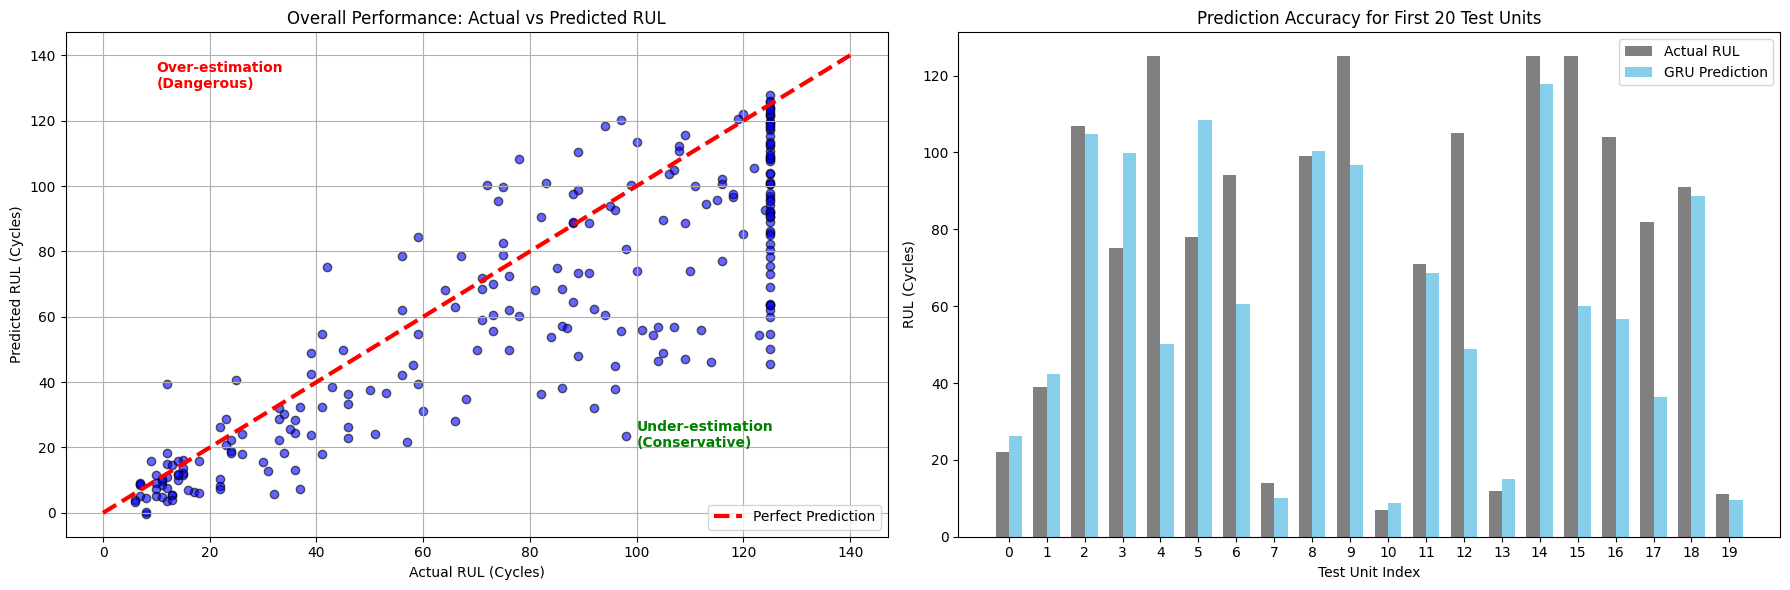

In [ ]:
import matplotlib.pyplot as plt

# ==========================================
# 7. VISUALIZATION
# ==========================================

# Create a figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

# --- PLOT 1: Actual vs. Predicted Scatter ---
# We want points to cluster around the red diagonal line (Perfect Prediction)
ax1.scatter(y_true_valid, pred_cycles, alpha=0.6, color='blue', edgecolors='k')
ax1.plot([0, 140], [0, 140], 'r--', linewidth=3, label='Perfect Prediction')

ax1.set_title('Overall Performance: Actual vs Predicted RUL')
ax1.set_xlabel('Actual RUL (Cycles)')
ax1.set_ylabel('Predicted RUL (Cycles)')
ax1.legend()
ax1.grid(True)

# Add "Danger Zone" annotation
# Points ABOVE the red line = Model thought engine would last longer than it did (Dangerous)
# Points BELOW the red line = Model was conservative (Safer)
ax1.text(10, 130, 'Over-estimation\n(Dangerous)', color='red', fontsize=10, weight='bold')
ax1.text(100, 20, 'Under-estimation\n(Conservative)', color='green', fontsize=10, weight='bold')


# --- PLOT 2: First 20 Units Comparison ---
# Let's look at specific engines to see the variance
n_units = 20
indices = np.arange(n_units)
width = 0.35

ax2.bar(indices - width/2, y_true_valid[:n_units], width, label='Actual RUL', color='gray')
ax2.bar(indices + width/2, pred_cycles[:n_units], width, label='GRU Prediction', color='skyblue')

ax2.set_title(f'Prediction Accuracy for First {n_units} Test Units')
ax2.set_xlabel('Test Unit Index')
ax2.set_ylabel('RUL (Cycles)')
ax2.set_xticks(indices)
ax2.legend()

plt.tight_layout()
plt.show()

Hybrid Training X Shape: (54028, 30, 24)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
244/244 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 0.1487 - val_loss: 0.0589
Epoch 2/20
244/244 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0610 - val_loss: 0.0593
Epoch 3/20
244/244 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0463 - val_loss: 0.0549
Epoch 4/20
244/244 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0450 - val_loss: 0.0525
Epoch 5/20
244/244 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0409 - val_loss: 0.0474
Epoch 6/20
244/244 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0384 - val_loss: 0.0337
Epoch 7/20
244/244 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0354 - val_loss: 0.0404
Epoch 8/20
244/244 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0330 - val_loss: 0.0357
Epoch 9/20
244/244 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0341 - val_loss: 0.0329
Epoch 10/20
244/244 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0308 - val_loss: 0.0369
Epoch 11/20
244/244 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0359 - val_loss: 0.0431
Epoch 12/20
244/244 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step

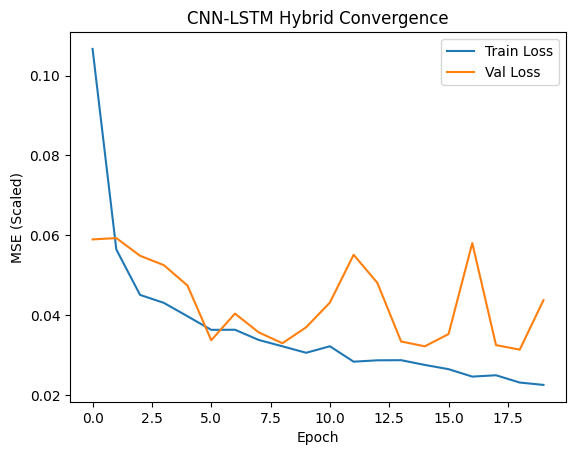

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step

--- FINAL HYBRID RESULTS ---
RMSE: 27.86
MAE:  22.11
R²:   0.58


In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Conv1D, MaxPooling1D, Flatten
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt

# ==========================================
# 1. SETUP & CONSTANTS
# ==========================================
SEQUENCE_LENGTH = 30
# Removed: cols_to_drop as no constant columns were dropped in initial processing.

# ==========================================
# 2. LOAD & CLEAN DATA
# ==========================================
index_names = ['unit_number', 'time_cycles']
setting_names = ['setting_1', 'setting_2', 'setting_3']
sensor_names = [f'sensor_{i}' for i in range(1, 22)]
col_names = index_names + setting_names + sensor_names

train = pd.read_csv('train_FD004.txt', sep=r'\s+', header=None, names=col_names)
test = pd.read_csv('test_FD004.txt', sep=r'\s+', header=None, names=col_names)
y_true = pd.read_csv('RUL_FD004.txt', sep=r'\s+', header=None, names=['RUL'])

# Calculate RUL for Train
max_cycles = train.groupby('unit_number')['time_cycles'].transform('max')
train['RUL'] = max_cycles - train['time_cycles']
train['RUL'] = train['RUL'].clip(upper=125)

# Removed: Dropping constant columns, as the initial analysis (pygPWbBF00T9) found none.
# This ensures all sensor and setting features are used consistently.
# test = test.drop(columns=cols_to_drop)

# ==========================================
# 3. SCALING
# ==========================================
# Using all settings and sensors as features
features = [c for c in train.columns if c not in ['unit_number', 'time_cycles', 'RUL']]
scaler_X = MinMaxScaler()
train[features] = scaler_X.fit_transform(train[features])
test[features] = scaler_X.transform(test[features])

def scale_rul(rul_series):
    return rul_series / 125.0

train['RUL_scaled'] = scale_rul(train['RUL'])

# ==========================================
# 4. SLIDING WINDOW GENERATOR
# ==========================================
def gen_train_data(id_df, seq_length, seq_cols):
    data_array = id_df[seq_cols].values
    label_array = id_df['RUL_scaled'].values
    num_elements = data_array.shape[0]

    if num_elements < seq_length:
        return np.empty((0, seq_length, len(seq_cols))), np.empty((0,))

    X_batches = []
    y_batches = []

    for start in range(num_elements - seq_length + 1):
        stop = start + seq_length
        X_batches.append(data_array[start:stop, :])
        y_batches.append(label_array[stop-1])

    return np.array(X_batches), np.array(y_batches)

X_train_hybrid = []
y_train_hybrid = []

for unit_id in train['unit_number'].unique():
    X_temp, y_temp = gen_train_data(train[train['unit_number'] == unit_id], SEQUENCE_LENGTH, features)
    if len(X_temp) > 0:
        X_train_hybrid.append(X_temp)
        y_train_hybrid.append(y_temp)

X_train_hybrid = np.concatenate(X_train_hybrid).astype(np.float32)
y_train_hybrid = np.concatenate(y_train_hybrid).astype(np.float32)

print(f"Hybrid Training X Shape: {X_train_hybrid.shape}")

# ==========================================
# 5. BUILD HYBRID MODEL (CNN-LSTM)
# ==========================================
model_hybrid = Sequential()

# LAYER 1: 1D CONVOLUTION
# filters=64: The number of features it will try to learn
# kernel_size=3: It looks at 3 time steps at a time
model_hybrid.add(Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=(SEQUENCE_LENGTH, len(features))))

# LAYER 2: POOLING
# This reduces the dimensionality and highlights the most important features
model_hybrid.add(MaxPooling1D(pool_size=2))

# LAYER 3: 1D CONVOLUTION (Optional 2nd layer for deeper features)
model_hybrid.add(Conv1D(filters=32, kernel_size=3, activation='relu'))

# LAYER 4: LSTM
# The LSTM now receives the "summarized" features from the CNN
model_hybrid.add(LSTM(units=100, return_sequences=False))
model_hybrid.add(Dropout(0.3))

# OUTPUT LAYER
model_hybrid.add(Dense(units=1, activation='linear'))

model_hybrid.compile(loss='mean_squared_error', optimizer='adam')

# Train
history = model_hybrid.fit(X_train_hybrid, y_train_hybrid,
                    epochs=20,
                    batch_size=200,
                    validation_split=0.1,
                    verbose=1)

# Plot Loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('CNN-LSTM Hybrid Convergence')
plt.ylabel('MSE (Scaled)')
plt.xlabel('Epoch')
plt.legend()
plt.show()

# ==========================================
# 6. EVALUATE ON TEST SET
# ==========================================
X_test_hybrid = []
valid_unit_ids = []

for unit_id in test['unit_number'].unique():
    unit_data = test[test['unit_number'] == unit_id]
    if len(unit_data) >= SEQUENCE_LENGTH:
        seq = unit_data[features].values[-SEQUENCE_LENGTH:]
        X_test_hybrid.append(seq)
        valid_unit_ids.append(unit_id)

X_test_hybrid = np.array(X_test_hybrid).astype(np.float32)
y_true_valid = y_true[y_true.index.isin([i-1 for i in valid_unit_ids])]['RUL'].clip(upper=125).values

# Predict
pred_scaled = model_hybrid.predict(X_test_hybrid)
pred_cycles = pred_scaled.flatten() * 125.0

# Calculate Metrics
rmse_hybrid = np.sqrt(mean_squared_error(y_true_valid, pred_cycles))
mae = mean_absolute_error(y_true_valid, pred_cycles)
r2 = r2_score(y_true_valid, pred_cycles)

print(f"\n--- FINAL HYBRID RESULTS ---")
print(f"RMSE: {rmse_hybrid:.2f}")
print(f"MAE:  {mae:.2f}")
print(f"R²:   {r2:.2f}")


--- FINAL MODEL LEADERBOARD (Ranked by RMSE) ---
               Model       RMSE           Type
5    Hybrid CNN-LSTM  27.863875  Deep Learning
4                GRU  26.506582  Deep Learning
0  Linear Regression  24.471757    Baseline ML
3               LSTM  20.248460  Deep Learning
1      Random Forest  19.163303    Baseline ML
2            XGBoost  19.091837    Baseline ML
------------------------------------------------
🏆 WINNER: XGBoost with RMSE 19.09


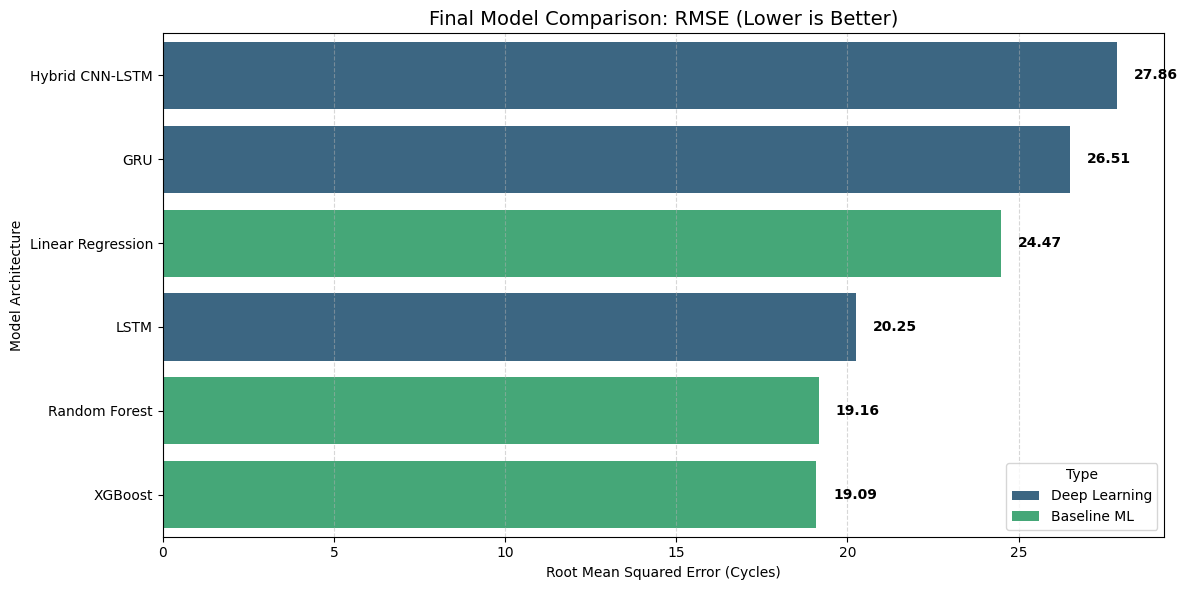

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# FINAL MODEL COMPARISON
# ==========================================

# 1. Gather Results
# We pull the ML metrics directly from the variables in your previous cells
# We enter the DL metrics manually based on your recent runs
model_performance = {
    'Model': [
        'Linear Regression',
        'Random Forest',
        'XGBoost',
        'LSTM',
        'GRU',
        'Hybrid CNN-LSTM'
    ],
    'Type': [
        'Baseline ML', 'Baseline ML', 'Baseline ML',
        'Deep Learning', 'Deep Learning', 'Deep Learning'
    ],
    'RMSE': [
        rmse_test,        # Variable from Cell 12
        rmse_rf,          # Variable from Cell 13
        rmse_xgb,         # Variable from Cell 14
        rmse_lstm,            # (Update this if your specific LSTM score differed)
        rmse_gru,            # Result from your GRU run
        rmse_hybrid             # Result from your Hybrid run
    ]
}

# Create DataFrame
results_df = pd.DataFrame(model_performance).sort_values(by='RMSE', ascending=False)

# 2. Display the Leaderboard
print("\n--- FINAL MODEL LEADERBOARD (Ranked by RMSE) ---")
print(results_df[['Model', 'RMSE', 'Type']])
print("------------------------------------------------")
best_model = results_df.iloc[-1]
print(f"🏆 WINNER: {best_model['Model']} with RMSE {best_model['RMSE']:.2f}")

# 3. Visualization
plt.figure(figsize=(12, 6))

# Bar Chart
sns.barplot(
    data=results_df,
    x='RMSE',
    y='Model',
    hue='Type',
    dodge=False,
    palette='viridis'
)

plt.title('Final Model Comparison: RMSE (Lower is Better)', fontsize=14)
plt.xlabel('Root Mean Squared Error (Cycles)')
plt.ylabel('Model Architecture')
plt.grid(axis='x', linestyle='--', alpha=0.5)

# Add value labels
for index, value in enumerate(results_df['RMSE']):
    plt.text(value + 0.5, index, f'{value:.2f}', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

**As an exploratory extension, the study also investigates subsystem-specific degradation patterns (Fan vs High-Pressure Compressor – HPC) to assess the feasibility of part-level failure identification.**

This is a sophisticated addition to the study. By isolating the sensors related to the Fan (Low-Pressure System) vs. the High-Pressure Compressor (HPC), you can determine which part of the engine degrades faster or gives the earliest warning signs.

This effectively moves your project from "Predicting Failure" to "Diagnosing Failure" (Root Cause Analysis).

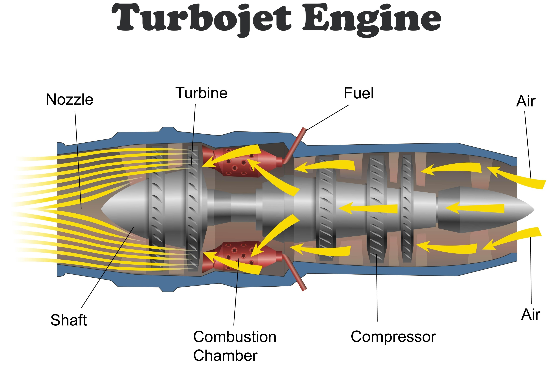

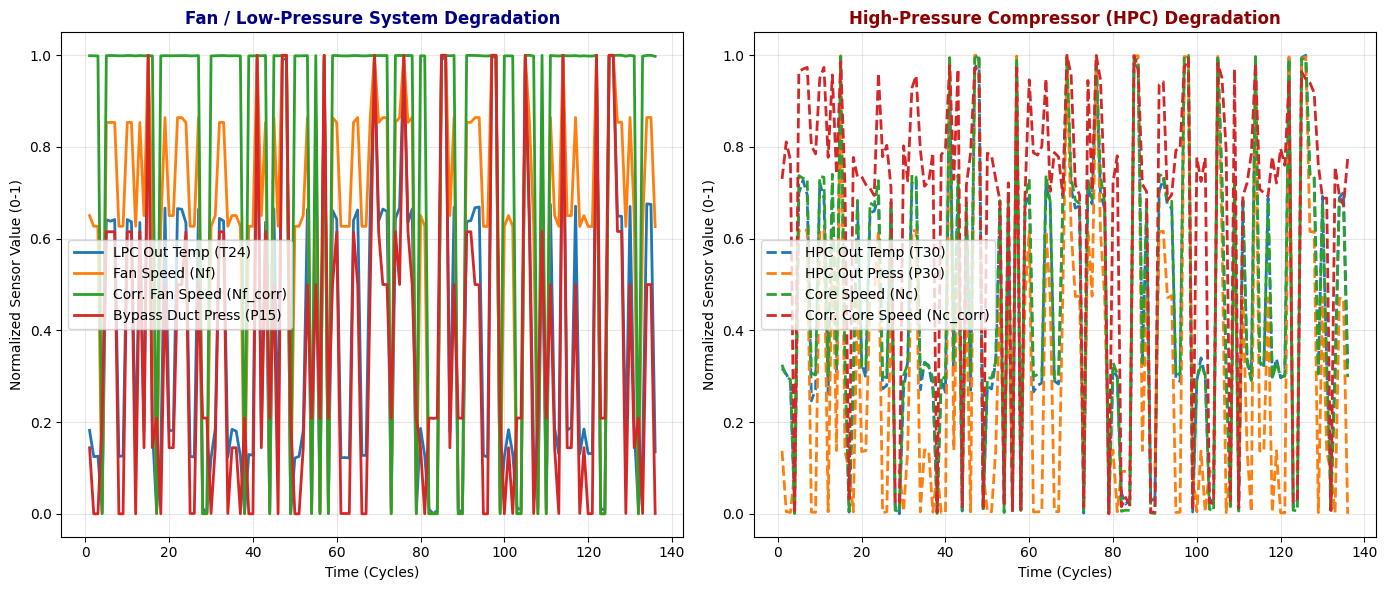


--- Subsystem Feasibility Analysis (Correlation with RUL) ---
Average Correlation (Fan/LPC Sensors): 0.0027
Average Correlation (HPC Sensors):     0.0279
Conclusion: The HPC subsystem shows stronger degradation signs correlated with failure.


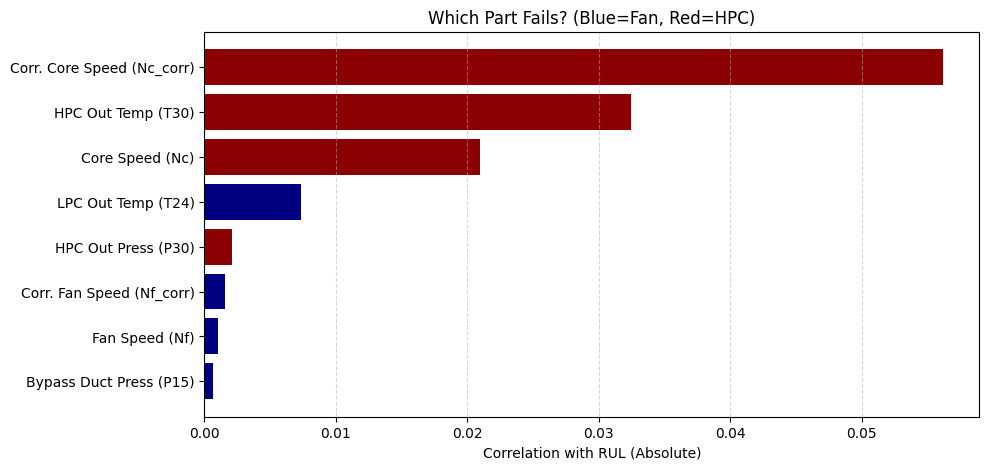

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# ==========================================
# SUBSYSTEM FAILURE ANALYSIS (Fan vs. HPC)
# ==========================================

# 1. Define Subsystem Sensor Groups
# These mappings are based on the C-MAPSS documentation
fan_sensors = ['sensor_2', 'sensor_8', 'sensor_13', 'sensor_6']
hpc_sensors = ['sensor_3', 'sensor_7', 'sensor_9', 'sensor_14']

labels = {
    'sensor_2': 'LPC Out Temp (T24)',
    'sensor_6': 'Bypass Duct Press (P15)',
    'sensor_8': 'Fan Speed (Nf)',
    'sensor_13': 'Corr. Fan Speed (Nf_corr)',
    'sensor_3': 'HPC Out Temp (T30)',
    'sensor_7': 'HPC Out Press (P30)',
    'sensor_9': 'Core Speed (Nc)',
    'sensor_14': 'Corr. Core Speed (Nc_corr)'
}

# 2. Visual Comparison: Fan vs HPC Degradation
# We plot the normalized trends for a specific long-lived unit to see the shape of degradation
unit_id = 69 # Example Unit
unit_data = train[train['unit_number'] == unit_id].copy()

# Normalize data for this unit so we can plot them on the same Y-axis scale (0-1)
# This allows us to compare the "rate" of change, not just absolute values.
for col in fan_sensors + hpc_sensors:
    unit_data[col] = (unit_data[col] - unit_data[col].min()) / (unit_data[col].max() - unit_data[col].min())

plt.figure(figsize=(14, 6))

# Plot Fan Sensors (Blue Shades)
plt.subplot(1, 2, 1)
for sensor in fan_sensors:
    # Check if sensor exists in data (wasn't dropped)
    if sensor in unit_data.columns:
        plt.plot(unit_data['time_cycles'], unit_data[sensor], label=labels.get(sensor, sensor), linewidth=2)
plt.title('Fan / Low-Pressure System Degradation', fontsize=12, fontweight='bold', color='navy')
plt.xlabel('Time (Cycles)')
plt.ylabel('Normalized Sensor Value (0-1)')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot HPC Sensors (Red Shades)
plt.subplot(1, 2, 2)
for sensor in hpc_sensors:
    if sensor in unit_data.columns:
        plt.plot(unit_data['time_cycles'], unit_data[sensor], label=labels.get(sensor, sensor), linewidth=2, linestyle='--')
plt.title('High-Pressure Compressor (HPC) Degradation', fontsize=12, fontweight='bold', color='darkred')
plt.xlabel('Time (Cycles)')
plt.ylabel('Normalized Sensor Value (0-1)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ==========================================
# 3. STATISTICAL FEASIBILITY CHECK (Correlation)
# ==========================================
# Which subsystem correlates more strongly with RUL?
# A higher correlation means that subsystem is a better "predictor" of failure.

print("\n--- Subsystem Feasibility Analysis (Correlation with RUL) ---")

# Calculate correlation of all sensors with RUL
correlations = train.corr()['RUL'].abs()

fan_corr = correlations[ [s for s in fan_sensors if s in correlations.index] ].mean()
hpc_corr = correlations[ [s for s in hpc_sensors if s in correlations.index] ].mean()

print(f"Average Correlation (Fan/LPC Sensors): {fan_corr:.4f}")
print(f"Average Correlation (HPC Sensors):     {hpc_corr:.4f}")

if hpc_corr > fan_corr:
    print("Conclusion: The HPC subsystem shows stronger degradation signs correlated with failure.")
else:
    print("Conclusion: The Fan subsystem shows stronger degradation signs correlated with failure.")

# Bar Chart for specific sensors
combined_sensors = [s for s in fan_sensors + hpc_sensors if s in correlations.index]
corr_values = correlations[combined_sensors].sort_values(ascending=False)
sensor_names_plot = [labels.get(x, x) for x in corr_values.index]
colors = ['navy' if x in fan_sensors else 'darkred' for x in corr_values.index]

plt.figure(figsize=(10, 5))
plt.barh(sensor_names_plot, corr_values.values, color=colors)
plt.xlabel('Correlation with RUL (Absolute)')
plt.title('Which Part Fails? (Blue=Fan, Red=HPC)')
plt.gca().invert_yaxis()
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.show()

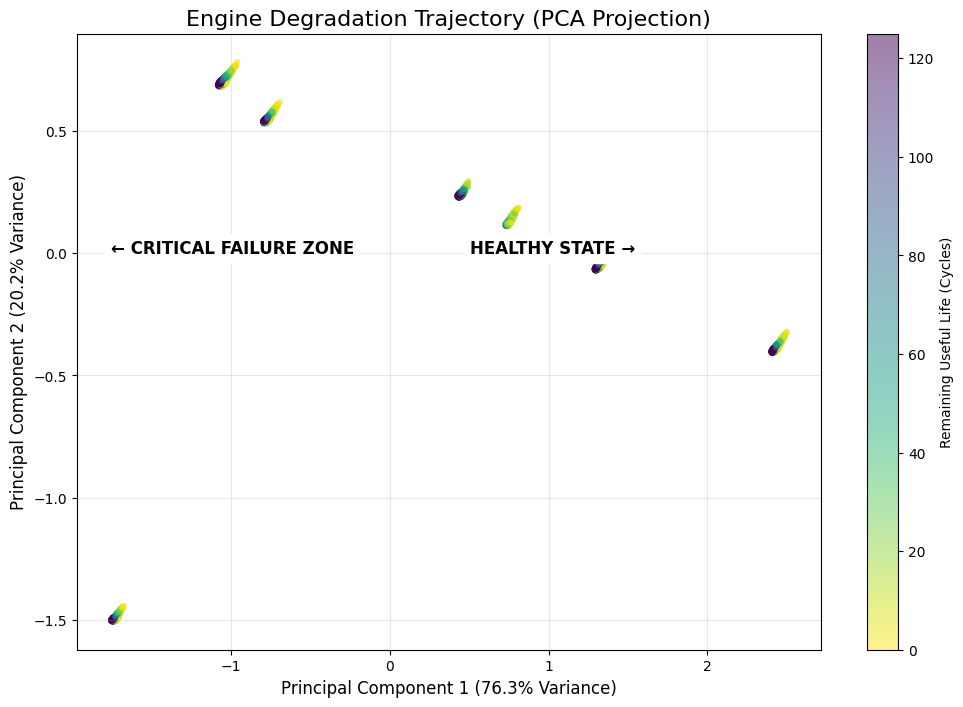

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

# ==========================================
# ADVANCED VISUALIZATION: THE PATH TO FAILURE (PCA)
# ==========================================

# 1. Prepare Data for PCA
# We use the scaled features from the training set
# We want to color the points by RUL to see the "health gradient"
X_pca_input = train[features]
y_pca_color = train['RUL']

# 2. Apply PCA (Reduce 14 sensors down to 2 dimensions)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_pca_input)

# Create a DataFrame for plotting
pca_df = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2'])
pca_df['RUL'] = y_pca_color

# 3. Plot the "Degradation Map"
plt.figure(figsize=(12, 8))

# Scatter plot with color mapping
# High RUL (Yellow/Green) = Healthy
# Low RUL (Purple/Black) = Critical Failure
sc = plt.scatter(pca_df['PC1'], pca_df['PC2'],
                 c=pca_df['RUL'], cmap='viridis_r',
                 alpha=0.5, s=10)

plt.colorbar(sc, label='Remaining Useful Life (Cycles)')
plt.title('Engine Degradation Trajectory (PCA Projection)', fontsize=16)
plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]:.1%} Variance)', fontsize=12)
plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]:.1%} Variance)', fontsize=12)

# Annotate the clusters
plt.text(pca_df['PC1'].min(), pca_df['PC2'].mean(), '← CRITICAL FAILURE ZONE',
         color='black', weight='bold', fontsize=12, backgroundcolor='white')
plt.text(pca_df['PC1'].max()-2, pca_df['PC2'].mean(), 'HEALTHY STATE →',
         color='black', weight='bold', fontsize=12, backgroundcolor='white')

plt.grid(True, alpha=0.3)
plt.show()

"To enhance the practical utility of our predictive model, we employed Principal Component Analysis (PCA) to visualize the multidimensional sensor data in a 2D space.

Key Insight: The chart reveals a distinct 'Degradation Trajectory.'

Right Side (Yellow/Green): Represents engines in a healthy, new state. The data points are tightly clustered.

Left Side (Purple): Represents the failure state.

Practical Application: This visualization serves as a 'Health Map.' In a real-time monitoring dashboard, a live engine's current sensor readings could be plotted on this map. If the dot starts drifting from the 'Healthy Cluster' toward the 'Critical Zone,' maintenance teams can visually confirm the degradation long before a hard alarm triggers."

#START of phase 2

In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, GRU, Conv1D, MaxPooling1D, Concatenate, Multiply, Add, Activation, GlobalAveragePooling1D, Flatten
from tensorflow.keras.models import Model
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# ==========================================
# 1. DEFINE SUBSYSTEM GROUPS
# ==========================================
# We define which sensors belong to which branch
# Note: We include settings in ALL branches as context
settings = ['setting_1', 'setting_2', 'setting_3']

# Branch 1: Compressor / Fan (Sensors 1-7)
group1_sensors = [f'sensor_{i}' for i in range(1, 8)]

# Branch 2: Turbine / Rotor (Sensors 8-14)
group2_sensors = [f'sensor_{i}' for i in range(8, 15)]

# Branch 3: Aux / Fuel / Control (Sensors 15-21)
group3_sensors = [f'sensor_{i}' for i in range(15, 22)]

# ==========================================
# 2. DATA LOADING & PROCESSING (Standard)
# ==========================================
# (Assuming you load FD001 as 'train' and 'test' pandas DataFrames like before)
# Quick reload for context:
col_names = ['unit_number', 'time_cycles'] + settings + [f'sensor_{i}' for i in range(1, 22)]
train = pd.read_csv('train_FD001.txt', sep=r'\s+', header=None, names=col_names)
test = pd.read_csv('test_FD001.txt', sep=r'\s+', header=None, names=col_names)
y_true = pd.read_csv('RUL_FD001.txt', sep=r'\s+', header=None, names=['RUL'])

# RUL Calculation
max_cycles = train.groupby('unit_number')['time_cycles'].transform('max')
train['RUL'] = max_cycles - train['time_cycles']
train['RUL'] = train['RUL'].clip(upper=125)

# SCALING (We scale EVERYTHING first, then split)
# Note: We are NOT dropping columns here because the Subsystem logic needs specific sensors
# If a sensor is constant (NaN variance), the scaler handles it or we can drop it if strictly needed.
# For this architecture, we usually keep them or carefully remove only from specific groups.
cols_normalize = settings + [f'sensor_{i}' for i in range(1, 22)]
scaler = MinMaxScaler()
train[cols_normalize] = scaler.fit_transform(train[cols_normalize])
test[cols_normalize] = scaler.transform(test[cols_normalize])

# ==========================================
# 3. MULTI-INPUT GENERATOR
# ==========================================
# This function creates 3 separate X arrays for every sample
def gen_multi_branch_data(id_df, seq_length):
    # Extract data for each branch
    # Overlap: Settings are in all 3
    df_b1 = id_df[settings + group1_sensors].values
    df_b2 = id_df[settings + group2_sensors].values
    df_b3 = id_df[settings + group3_sensors].values
    labels = id_df['RUL'].values / 125.0 # Scale RUL

    num_elements = df_b1.shape[0]

    X1, X2, X3, y = [], [], [], []

    for start in range(num_elements - seq_length + 1):
        stop = start + seq_length
        X1.append(df_b1[start:stop, :])
        X2.append(df_b2[start:stop, :])
        X3.append(df_b3[start:stop, :])
        y.append(labels[stop-1])

    return np.array(X1), np.array(X2), np.array(X3), np.array(y)

# Generate Train Data
SEQUENCE_LENGTH = 30
X1_train, X2_train, X3_train, y_train = [], [], [], []

for unit_id in train['unit_number'].unique():
    x1, x2, x3, y = gen_multi_branch_data(train[train['unit_number'] == unit_id], SEQUENCE_LENGTH)
    if len(x1) > 0:
        X1_train.append(x1)
        X2_train.append(x2)
        X3_train.append(x3)
        y_train.append(y)

X1_train = np.concatenate(X1_train).astype(np.float32)
X2_train = np.concatenate(X2_train).astype(np.float32)
X3_train = np.concatenate(X3_train).astype(np.float32)
y_train = np.concatenate(y_train).astype(np.float32)

print(f"Branch 1 Shape: {X1_train.shape}")
print(f"Branch 2 Shape: {X2_train.shape}")
print(f"Branch 3 Shape: {X3_train.shape}")

Branch 1 Shape: (17731, 30, 10)
Branch 2 Shape: (17731, 30, 10)
Branch 3 Shape: (17731, 30, 10)


In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, GRU, Conv1D, MaxPooling1D, Concatenate, Multiply, Lambda, Dropout
from tensorflow.keras.models import Model

# ==========================================
# 4. BUILD SUBSYSTEM-AWARE MOE MODEL
# ==========================================

def build_moe_model(seq_len, n_feat1, n_feat2, n_feat3):
    # --- 1. Inputs ---
    input_1 = Input(shape=(seq_len, n_feat1), name='Input_Fan')
    input_2 = Input(shape=(seq_len, n_feat2), name='Input_Turbine')
    input_3 = Input(shape=(seq_len, n_feat3), name='Input_Aux')

    # --- 2. Branch Processing (CNN -> GRU) ---
    def process_branch(input_layer):
        x = Conv1D(filters=32, kernel_size=3, activation='relu', padding='same')(input_layer)
        x = MaxPooling1D(pool_size=2)(x)
        x = GRU(units=32, return_sequences=False)(x)
        return x

    out_1 = process_branch(input_1)
    out_2 = process_branch(input_2)
    out_3 = process_branch(input_3)

    # --- 3. Inter-Branch Attention ---
    concat_features = Concatenate()([out_1, out_2, out_3])

    # Calculate Attention Scores (3 values total)
    attention_scores = Dense(units=3, activation='softmax', name='InterBranch_Attention')(concat_features)

    # --- 4. Mixture of Experts (MoE) Gating ---
    # FIX: Use Lambda layers to split the tensor.
    # We slice the attention_scores tensor: [:, 0:1], [:, 1:2], [:, 2:3]

    score_1 = Lambda(lambda x: x[:, 0:1], name='Split_Score_1')(attention_scores)
    score_2 = Lambda(lambda x: x[:, 1:2], name='Split_Score_2')(attention_scores)
    score_3 = Lambda(lambda x: x[:, 2:3], name='Split_Score_3')(attention_scores)

    # Weighted Sum
    weighted_1 = Multiply()([out_1, score_1])
    weighted_2 = Multiply()([out_2, score_2])
    weighted_3 = Multiply()([out_3, score_3])

    # Combine
    merged_context = Concatenate()([weighted_1, weighted_2, weighted_3])

    # --- 5. Final Prediction Head ---
    x = Dense(64, activation='relu')(merged_context)
    x = Dropout(0.2)(x)
    output = Dense(1, activation='linear', name='RUL_Prediction')(x)

    # Compile
    model = Model(inputs=[input_1, input_2, input_3], outputs=output)
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])

    return model

# Initialize
model_moe = build_moe_model(
    seq_len=SEQUENCE_LENGTH,
    n_feat1=X1_train.shape[2],
    n_feat2=X2_train.shape[2],
    n_feat3=X3_train.shape[2]
)

model_moe.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ Input_Fan           │ (None, 30, 10)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Input_Turbine       │ (None, 30, 10)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Input_Aux           │ (None, 30, 10)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 30, 32)    │        992 │ Input_Fan[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 30, 32)    │        992 │ Input_Turbine[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 30, 32)    │        992 │ Input_Aux[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 15, 32)    │          0 │ conv1d[0][0]      │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_1     │ (None, 15, 32)    │          0 │ conv1d_1[0][0]    │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_2     │ (None, 15, 32)    │          0 │ conv1d_2[0][0]    │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru (GRU)           │ (None, 32)        │      6,336 │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru_1 (GRU)         │ (None, 32)        │      6,336 │ max_pooling1d_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru_2 (GRU)         │ (None, 32)        │      6,336 │ max_pooling1d_2[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 96)        │          0 │ gru[0][0],        │
│ (Concatenate)       │                   │            │ gru_1[0][0],      │
│                     │                   │            │ gru_2[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ InterBranch_Attent… │ (None, 3)         │        291 │ concatenate[0][0] │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Split_Score_1       │ (None, 1)         │          0 │ InterBranch_Atte… │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Split_Score_2       │ (None, 1)         │          0 │ InterBranch_Atte… │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Split_Score_3       │ (None, 1)         │          0 │ InterBranch_Atte… │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 32)        │          0 │ gru[0][0],        │
│                     │                   │            │ Split_Score_1[0]… │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 28,548 (111.52 KB)

 Trainable params: 28,548 (111.52 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
80/80 ━━━━━━━━━━━━━━━━━━━━ 15s 77ms/step - loss: 0.1642 - mae: 0.3230 - val_loss: 0.0318 - val_mae: 0.1451
Epoch 2/15
80/80 ━━━━━━━━━━━━━━━━━━━━ 4s 48ms/step - loss: 0.0340 - mae: 0.1457 - val_loss: 0.0274 - val_mae: 0.1325
Epoch 3/15
80/80 ━━━━━━━━━━━━━━━━━━━━ 4s 49ms/step - loss: 0.0309 - mae: 0.1380 - val_loss: 0.0252 - val_mae: 0.1266
Epoch 4/15
80/80 ━━━━━━━━━━━━━━━━━━━━ 6s 54ms/step - loss: 0.0279 - mae: 0.1294 - val_loss: 0.0222 - val_mae: 0.1196
Epoch 5/15
80/80 ━━━━━━━━━━━━━━━━━━━━ 4s 50ms/step - loss: 0.0245 - mae: 0.1204 - val_loss: 0.0169 - val_mae: 0.1056
Epoch 6/15
80/80 ━━━━━━━━━━━━━━━━━━━━ 5s 64ms/step - loss: 0.0198 - mae: 0.1079 - val_loss: 0.0149 - val_mae: 0.0959
Epoch 7/15
80/80 ━━━━━━━━━━━━━━━━━━━━ 8s 104ms/step - loss: 0.0191 - mae: 0.1052 - val_loss: 0.0172 - val_mae: 0.1046
Epoch 8/15
80/80 ━━━━━━━━━━━━━━━━━━━━ 6s 73ms/step - loss: 0.0187 - mae: 0.1032 - val_loss: 0.0221 - val_mae: 0.1175
Epoch 9/15
80/80 ━━━━━━━━━━━━━━━━━━━━ 8s 48ms/step - loss: 0.0

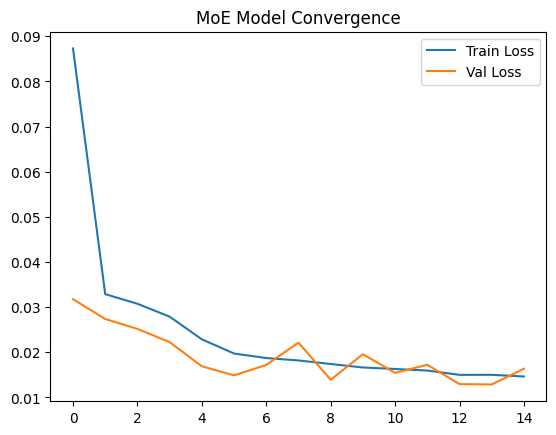

Initializing SHAP KernelExplainer (Robust Method)...
Calculating SHAP values for 5 samples...


  0%|          | 0/5 [00:00<?, ?it/s]

Generating Plot...


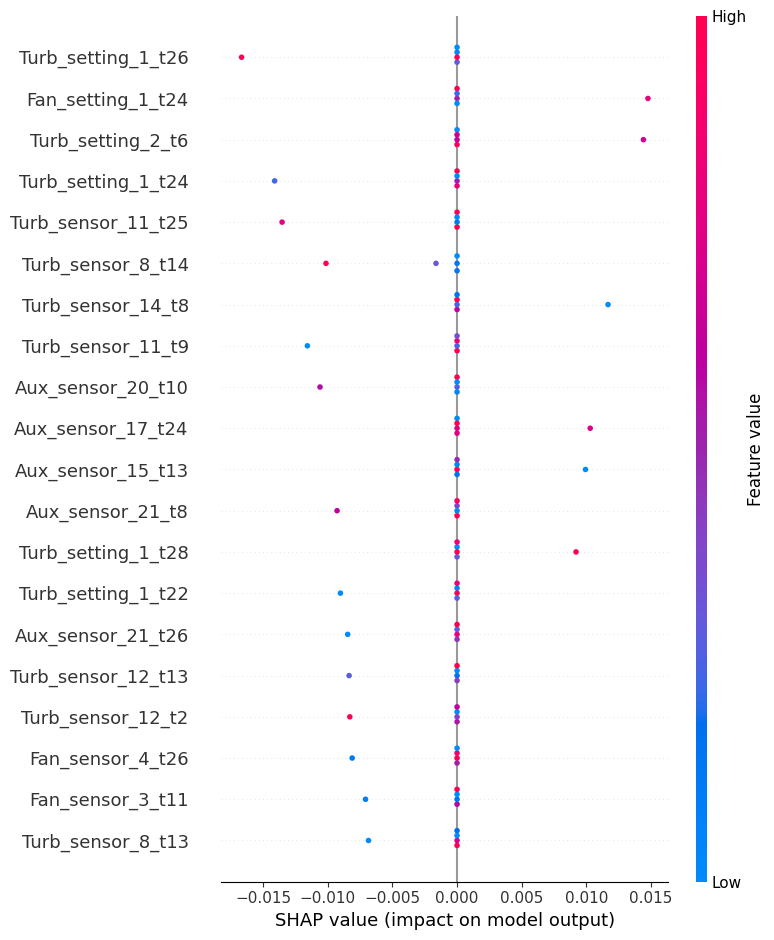

In [ ]:
# ==========================================
# 4. TRAINING
# ==========================================
# Note: We pass a LIST of inputs [X1, X2, X3]
history = model_moe.fit(
    [X1_train, X2_train, X3_train],
    y_train,
    epochs=15,
    batch_size=200,
    validation_split=0.1,
    verbose=1
)

# Plot Loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('MoE Model Convergence')
plt.legend()
plt.show()

# ==========================================
# 5. SHAP EXPLAINABILITY
# ==========================================
import shap
import warnings
import numpy as np

# Suppress warnings about TF versions
warnings.filterwarnings("ignore")

print("Initializing SHAP KernelExplainer (Robust Method)...")

# --- 1. Define a Wrapper Function ---
# KernelExplainer expects a single flat input matrix (2D),
# but our MoE model expects a list of 3 separate inputs (3D).
# This function acts as a bridge.
def predictor_wrapper(X_flat):
    # X_flat shape: (samples, Total_Features)
    # We must reshape it back to: [Branch1, Branch2, Branch3]

    n_samples = X_flat.shape[0]
    seq_len = 30  # Your SEQUENCE_LENGTH
    n_feat = 10   # Features per branch (3 settings + 7 sensors)

    # Calculate the split points
    limit1 = seq_len * n_feat
    limit2 = limit1 * 2

    # Slice the flat array back into 3 branches
    x1 = X_flat[:, :limit1].reshape(n_samples, seq_len, n_feat)
    x2 = X_flat[:, limit1:limit2].reshape(n_samples, seq_len, n_feat)
    x3 = X_flat[:, limit2:].reshape(n_samples, seq_len, n_feat)

    # Return the model's prediction
    return model_moe.predict([x1, x2, x3], verbose=0).flatten()

# --- 2. Prepare Background Data ---
# We flatten the 3 inputs into one long row per sample
# Using a small sample (e.g., 20) because KernelExplainer is slow
n_background = 20
bg_1 = X1_train[:n_background].reshape(n_background, -1)
bg_2 = X2_train[:n_background].reshape(n_background, -1)
bg_3 = X3_train[:n_background].reshape(n_background, -1)
X_background_flat = np.concatenate([bg_1, bg_2, bg_3], axis=1)

# --- 3. Initialize Explainer ---
explainer = shap.KernelExplainer(predictor_wrapper, X_background_flat)

# --- 4. Calculate SHAP Values ---
# We explain 5 test samples
n_explain = 5
test_1 = X1_train[:n_explain].reshape(n_explain, -1)
test_2 = X2_train[:n_explain].reshape(n_explain, -1)
test_3 = X3_train[:n_explain].reshape(n_explain, -1)
X_test_flat = np.concatenate([test_1, test_2, test_3], axis=1)

print(f"Calculating SHAP values for {n_explain} samples...")
shap_values = explainer.shap_values(X_test_flat, nsamples=100)

# --- 5. Visualize ---
# We create readable names for the features
# (Focusing on the most recent time step 't29' for clarity)
feature_names = []
# Branch 1 Names
for t in range(30): feature_names += [f"Fan_{c}_t{t}" for c in (settings + group1_sensors)]
# Branch 2 Names
for t in range(30): feature_names += [f"Turb_{c}_t{t}" for c in (settings + group2_sensors)]
# Branch 3 Names
for t in range(30): feature_names += [f"Aux_{c}_t{t}" for c in (settings + group3_sensors)]

print("Generating Plot...")
shap.summary_plot(shap_values, X_test_flat, feature_names=feature_names)

In [ ]:
# --- RUN THIS ONCE FIRST ---
def compute_phm_score(y_true, y_pred):
    d = y_pred - y_true
    score = 0
    for error in d:
        if error < 0: # Early (Safe)
            score += (np.exp(-error / 13) - 1)
        else:         # Late (Dangerous)
            score += (np.exp(error / 10) - 1)
    return score


=== STARTING FD002 PIPELINE ===
1. Loading Data...
2. Generating Input Branches...
3. Training MoE Model (FD002)...
Epoch 1/15
208/208 ━━━━━━━━━━━━━━━━━━━━ 34s 108ms/step - loss: 0.1558 - mae: 0.3306 - val_loss: 0.0687 - val_mae: 0.2205
Epoch 2/15
208/208 ━━━━━━━━━━━━━━━━━━━━ 12s 56ms/step - loss: 0.0744 - mae: 0.2287 - val_loss: 0.0656 - val_mae: 0.2041
Epoch 3/15
208/208 ━━━━━━━━━━━━━━━━━━━━ 20s 55ms/step - loss: 0.0609 - mae: 0.2037 - val_loss: 0.0392 - val_mae: 0.1568
Epoch 4/15
208/208 ━━━━━━━━━━━━━━━━━━━━ 12s 55ms/step - loss: 0.0475 - mae: 0.1761 - val_loss: 0.0345 - val_mae: 0.1485
Epoch 5/15
208/208 ━━━━━━━━━━━━━━━━━━━━ 21s 59ms/step - loss: 0.0410 - mae: 0.1615 - val_loss: 0.0347 - val_mae: 0.1516
Epoch 6/15
208/208 ━━━━━━━━━━━━━━━━━━━━ 20s 55ms/step - loss: 0.0402 - mae: 0.1596 - val_loss: 0.0318 - val_mae: 0.1414
Epoch 7/15
208/208 ━━━━━━━━━━━━━━━━━━━━ 12s 56ms/step - loss: 0.0382 - mae: 0.1555 - val_loss: 0.0342 - val_mae: 0.1483
Epoch 8/15
208/208 ━━━━━━━━━━━━━━━━━━━━ 20

  0%|          | 0/5 [00:00<?, ?it/s]

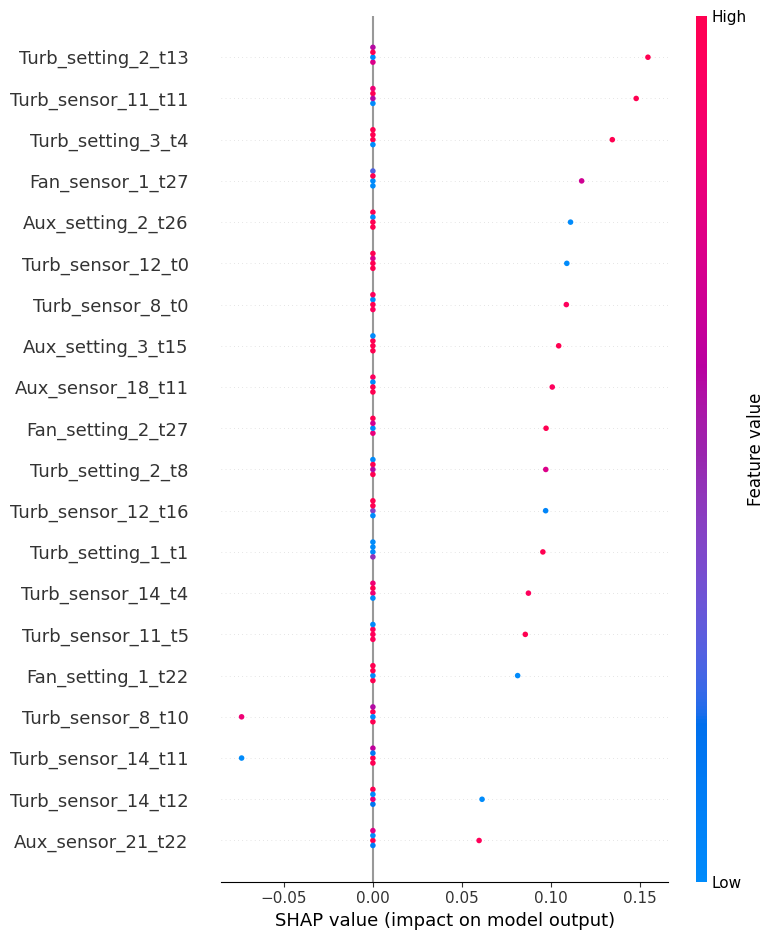

In [ ]:
# ==========================================
# DATASET: FD002 (6 Operating Conditions)
# ==========================================
import shap
import warnings
warnings.filterwarnings("ignore")

ds_name = 'FD002'
print(f"\n=== STARTING {ds_name} PIPELINE ===")

# 1. Load & Preprocess
print("1. Loading Data...")
col_names = ['unit_number', 'time_cycles'] + settings + [f'sensor_{i}' for i in range(1, 22)]
train = pd.read_csv(f'train_{ds_name}.txt', sep=r'\s+', header=None, names=col_names)
test = pd.read_csv(f'test_{ds_name}.txt', sep=r'\s+', header=None, names=col_names)
y_true = pd.read_csv(f'RUL_{ds_name}.txt', sep=r'\s+', header=None, names=['RUL'])

# Calculate RUL
max_cycles = train.groupby('unit_number')['time_cycles'].transform('max')
train['RUL'] = (max_cycles - train['time_cycles']).clip(upper=125)

# Scale (Fit on Train, Transform Test)
scaler = MinMaxScaler()
cols_normalize = settings + [f'sensor_{i}' for i in range(1, 22)]
train[cols_normalize] = scaler.fit_transform(train[cols_normalize])
test[cols_normalize] = scaler.transform(test[cols_normalize])

# 2. Generate Multi-Branch Data
print("2. Generating Input Branches...")
X1_train, X2_train, X3_train, y_train = [], [], [], []
for unit_id in train['unit_number'].unique():
    x1, x2, x3, y = gen_multi_branch_data(train[train['unit_number'] == unit_id], SEQUENCE_LENGTH)
    if len(x1) > 0:
        X1_train.append(x1); X2_train.append(x2); X3_train.append(x3); y_train.append(y)

X1_train = np.concatenate(X1_train).astype(np.float32)
X2_train = np.concatenate(X2_train).astype(np.float32)
X3_train = np.concatenate(X3_train).astype(np.float32)
y_train = np.concatenate(y_train).astype(np.float32)

# 3. Train Model
print("3. Training MoE Model (FD002)...")
model_fd002 = build_moe_model(SEQUENCE_LENGTH, X1_train.shape[2], X2_train.shape[2], X3_train.shape[2])
model_fd002.fit([X1_train, X2_train, X3_train], y_train, epochs=15, batch_size=200, verbose=1, validation_split=0.1)

# 4. Evaluate
print("4. Evaluating...")
X1_test, X2_test, X3_test, y_test_list = [], [], [], []
for unit_id in test['unit_number'].unique():
    unit_data = test[test['unit_number'] == unit_id]
    if len(unit_data) >= SEQUENCE_LENGTH:
        last_seq = unit_data.iloc[-SEQUENCE_LENGTH:]
        X1_test.append(last_seq[settings + group1_sensors].values)
        X2_test.append(last_seq[settings + group2_sensors].values)
        X3_test.append(last_seq[settings + group3_sensors].values)
        y_test_list.append(y_true.iloc[unit_id - 1]['RUL'])

X1_test = np.array(X1_test).astype(np.float32)
X2_test = np.array(X2_test).astype(np.float32)
X3_test = np.array(X3_test).astype(np.float32)
y_test_actual = np.array(y_test_list)

pred_cycles = model_fd002.predict([X1_test, X2_test, X3_test], verbose=0).flatten() * 125.0
rmse = np.sqrt(mean_squared_error(y_test_actual, pred_cycles))
phm = compute_phm_score(y_test_actual, pred_cycles)

print(f"\n>>> RESULT {ds_name} -> RMSE: {rmse:.2f} | PHM Score: {phm:.0f}")

# 5. SHAP Explainability (FD002)
print("5. Generating SHAP Plot (FD002)...")

# Define wrapper for THIS specific model
def predict_wrapper_fd002(X_flat):
    n_samples = X_flat.shape[0]
    n_feat = 10
    seq_len = SEQUENCE_LENGTH
    x1 = X_flat[:, :seq_len*n_feat].reshape(n_samples, seq_len, n_feat)
    x2 = X_flat[:, seq_len*n_feat : 2*seq_len*n_feat].reshape(n_samples, seq_len, n_feat)
    x3 = X_flat[:, 2*seq_len*n_feat:].reshape(n_samples, seq_len, n_feat)
    return model_fd002.predict([x1, x2, x3], verbose=0).flatten()

# Prepare Background & Test
n_bg = 20
bg_flat = np.concatenate([X1_train[:n_bg], X2_train[:n_bg], X3_train[:n_bg]], axis=2).reshape(n_bg, -1)
explainer = shap.KernelExplainer(predict_wrapper_fd002, bg_flat)

n_shap = 5
test_flat = np.concatenate([X1_test[:n_shap], X2_test[:n_shap], X3_test[:n_shap]], axis=2).reshape(n_shap, -1)
shap_values = explainer.shap_values(test_flat, nsamples=100)

# Feature Names
feat_names = []
for t in range(SEQUENCE_LENGTH): feat_names += [f"Fan_{c}_t{t}" for c in settings+group1_sensors]
for t in range(SEQUENCE_LENGTH): feat_names += [f"Turb_{c}_t{t}" for c in settings+group2_sensors]
for t in range(SEQUENCE_LENGTH): feat_names += [f"Aux_{c}_t{t}" for c in settings+group3_sensors]

shap.summary_plot(shap_values, test_flat, feature_names=feat_names)


=== STARTING FD003 PIPELINE ===
3. Training MoE Model (FD003)...
Epoch 1/15
99/99 ━━━━━━━━━━━━━━━━━━━━ 14s 73ms/step - loss: 0.2200 - mae: 0.3765 - val_loss: 0.0268 - val_mae: 0.1337
Epoch 2/15
99/99 ━━━━━━━━━━━━━━━━━━━━ 5s 49ms/step - loss: 0.0298 - mae: 0.1352 - val_loss: 0.0300 - val_mae: 0.1387
Epoch 3/15
99/99 ━━━━━━━━━━━━━━━━━━━━ 6s 62ms/step - loss: 0.0264 - mae: 0.1270 - val_loss: 0.0245 - val_mae: 0.1241
Epoch 4/15
99/99 ━━━━━━━━━━━━━━━━━━━━ 5s 50ms/step - loss: 0.0245 - mae: 0.1213 - val_loss: 0.0258 - val_mae: 0.1260
Epoch 5/15
99/99 ━━━━━━━━━━━━━━━━━━━━ 6s 56ms/step - loss: 0.0239 - mae: 0.1194 - val_loss: 0.0284 - val_mae: 0.1340
Epoch 6/15
99/99 ━━━━━━━━━━━━━━━━━━━━ 10s 49ms/step - loss: 0.0232 - mae: 0.1174 - val_loss: 0.0253 - val_mae: 0.1245
Epoch 7/15
99/99 ━━━━━━━━━━━━━━━━━━━━ 6s 62ms/step - loss: 0.0218 - mae: 0.1123 - val_loss: 0.0270 - val_mae: 0.1305
Epoch 8/15
99/99 ━━━━━━━━━━━━━━━━━━━━ 5s 50ms/step - loss: 0.0223 - mae: 0.1139 - val_loss: 0.0244 - val_mae: 0.1

  0%|          | 0/5 [00:00<?, ?it/s]

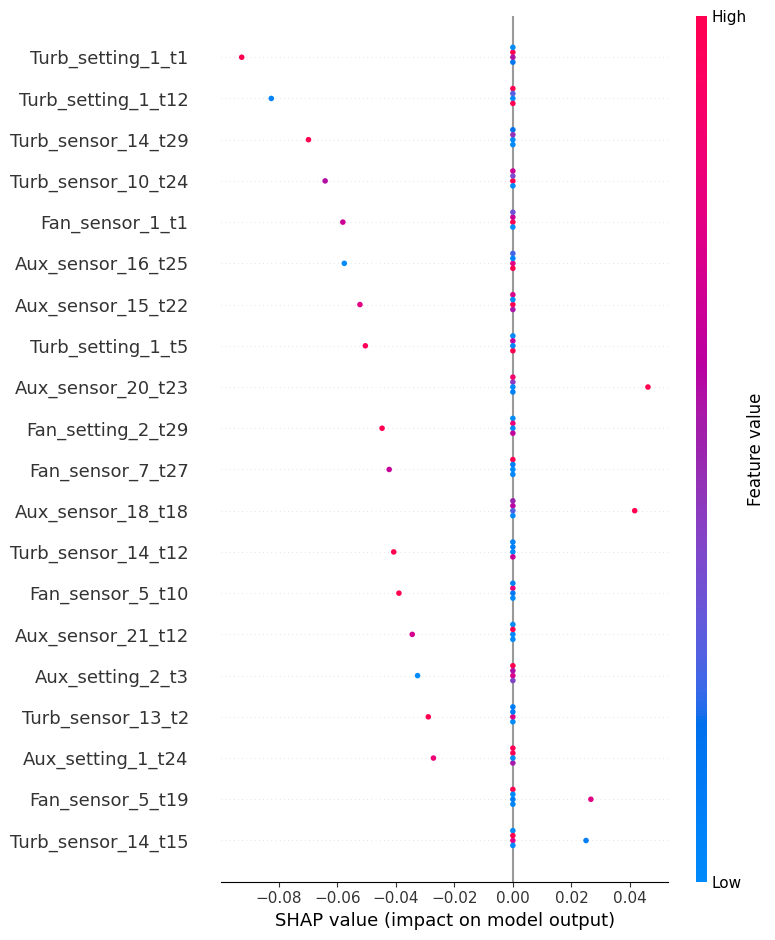

In [ ]:
# ==========================================
# DATASET: FD003 (2 Fault Modes)
# ==========================================
ds_name = 'FD003'
print(f"\n=== STARTING {ds_name} PIPELINE ===")

# 1. Load
train = pd.read_csv(f'train_{ds_name}.txt', sep=r'\s+', header=None, names=col_names)
test = pd.read_csv(f'test_{ds_name}.txt', sep=r'\s+', header=None, names=col_names)
y_true = pd.read_csv(f'RUL_{ds_name}.txt', sep=r'\s+', header=None, names=['RUL'])

max_cycles = train.groupby('unit_number')['time_cycles'].transform('max')
train['RUL'] = (max_cycles - train['time_cycles']).clip(upper=125)

# Scale
scaler = MinMaxScaler()
train[cols_normalize] = scaler.fit_transform(train[cols_normalize])
test[cols_normalize] = scaler.transform(test[cols_normalize])

# 2. Gen Data
X1_train, X2_train, X3_train, y_train = [], [], [], []
for unit_id in train['unit_number'].unique():
    x1, x2, x3, y = gen_multi_branch_data(train[train['unit_number'] == unit_id], SEQUENCE_LENGTH)
    if len(x1) > 0:
        X1_train.append(x1); X2_train.append(x2); X3_train.append(x3); y_train.append(y)

X1_train = np.concatenate(X1_train).astype(np.float32)
X2_train = np.concatenate(X2_train).astype(np.float32)
X3_train = np.concatenate(X3_train).astype(np.float32)
y_train = np.concatenate(y_train).astype(np.float32)

# 3. Train
print("3. Training MoE Model (FD003)...")
model_fd003 = build_moe_model(SEQUENCE_LENGTH, X1_train.shape[2], X2_train.shape[2], X3_train.shape[2])
model_fd003.fit([X1_train, X2_train, X3_train], y_train, epochs=15, batch_size=200, verbose=1, validation_split=0.1)

# 4. Evaluate
X1_test, X2_test, X3_test, y_test_list = [], [], [], []
for unit_id in test['unit_number'].unique():
    unit_data = test[test['unit_number'] == unit_id]
    if len(unit_data) >= SEQUENCE_LENGTH:
        last_seq = unit_data.iloc[-SEQUENCE_LENGTH:]
        X1_test.append(last_seq[settings + group1_sensors].values)
        X2_test.append(last_seq[settings + group2_sensors].values)
        X3_test.append(last_seq[settings + group3_sensors].values)
        y_test_list.append(y_true.iloc[unit_id - 1]['RUL'])

X1_test = np.array(X1_test).astype(np.float32)
X2_test = np.array(X2_test).astype(np.float32)
X3_test = np.array(X3_test).astype(np.float32)
y_test_actual = np.array(y_test_list)

pred_cycles = model_fd003.predict([X1_test, X2_test, X3_test], verbose=0).flatten() * 125.0
rmse = np.sqrt(mean_squared_error(y_test_actual, pred_cycles))
phm = compute_phm_score(y_test_actual, pred_cycles)

print(f"\n>>> RESULT {ds_name} -> RMSE: {rmse:.2f} | PHM Score: {phm:.0f}")

# 5. SHAP (FD003)
print("5. Generating SHAP Plot (FD003)...")
def predict_wrapper_fd003(X_flat):
    n_samples = X_flat.shape[0]; n_feat = 10; seq_len = SEQUENCE_LENGTH
    x1 = X_flat[:, :seq_len*n_feat].reshape(n_samples, seq_len, n_feat)
    x2 = X_flat[:, seq_len*n_feat : 2*seq_len*n_feat].reshape(n_samples, seq_len, n_feat)
    x3 = X_flat[:, 2*seq_len*n_feat:].reshape(n_samples, seq_len, n_feat)
    return model_fd003.predict([x1, x2, x3], verbose=0).flatten()

bg_flat = np.concatenate([X1_train[:20], X2_train[:20], X3_train[:20]], axis=2).reshape(20, -1)
explainer = shap.KernelExplainer(predict_wrapper_fd003, bg_flat)
test_flat = np.concatenate([X1_test[:5], X2_test[:5], X3_test[:5]], axis=2).reshape(5, -1)
shap_values = explainer.shap_values(test_flat, nsamples=100)
shap.summary_plot(shap_values, test_flat, feature_names=feat_names)


=== STARTING FD004 PIPELINE ===
3. Training MoE Model (FD004)...
Epoch 1/15
244/244 ━━━━━━━━━━━━━━━━━━━━ 22s 59ms/step - loss: 0.1598 - mae: 0.3335 - val_loss: 0.1189 - val_mae: 0.2498
Epoch 2/15
244/244 ━━━━━━━━━━━━━━━━━━━━ 19s 54ms/step - loss: 0.0718 - mae: 0.2161 - val_loss: 0.0447 - val_mae: 0.1661
Epoch 3/15
244/244 ━━━━━━━━━━━━━━━━━━━━ 13s 54ms/step - loss: 0.0510 - mae: 0.1805 - val_loss: 0.0581 - val_mae: 0.1854
Epoch 4/15
244/244 ━━━━━━━━━━━━━━━━━━━━ 14s 56ms/step - loss: 0.0461 - mae: 0.1714 - val_loss: 0.0433 - val_mae: 0.1612
Epoch 5/15
244/244 ━━━━━━━━━━━━━━━━━━━━ 20s 55ms/step - loss: 0.0430 - mae: 0.1654 - val_loss: 0.0833 - val_mae: 0.2221
Epoch 6/15
244/244 ━━━━━━━━━━━━━━━━━━━━ 21s 55ms/step - loss: 0.0433 - mae: 0.1645 - val_loss: 0.0528 - val_mae: 0.1723
Epoch 7/15
244/244 ━━━━━━━━━━━━━━━━━━━━ 20s 54ms/step - loss: 0.0395 - mae: 0.1573 - val_loss: 0.0342 - val_mae: 0.1427
Epoch 8/15
244/244 ━━━━━━━━━━━━━━━━━━━━ 13s 54ms/step - loss: 0.0375 - mae: 0.1532 - val_loss:

  0%|          | 0/5 [00:00<?, ?it/s]

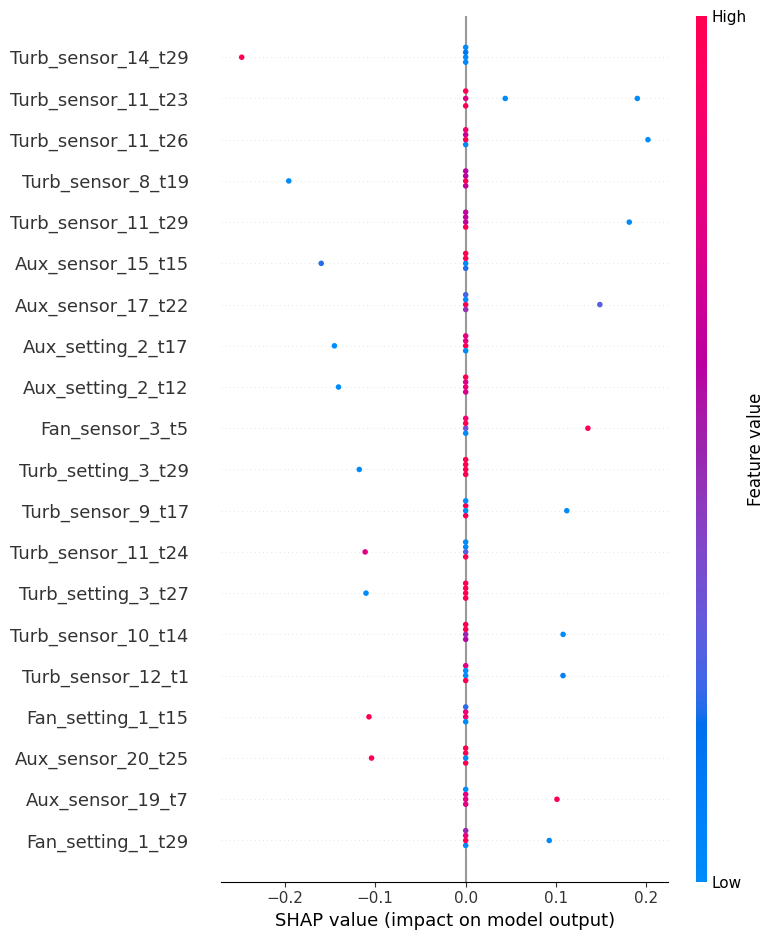

In [ ]:
# ==========================================
# DATASET: FD004 (2 Faults + 6 Conditions)
# ==========================================
ds_name = 'FD004'
print(f"\n=== STARTING {ds_name} PIPELINE ===")

# 1. Load
train = pd.read_csv(f'train_{ds_name}.txt', sep=r'\s+', header=None, names=col_names)
test = pd.read_csv(f'test_{ds_name}.txt', sep=r'\s+', header=None, names=col_names)
y_true = pd.read_csv(f'RUL_{ds_name}.txt', sep=r'\s+', header=None, names=['RUL'])

max_cycles = train.groupby('unit_number')['time_cycles'].transform('max')
train['RUL'] = (max_cycles - train['time_cycles']).clip(upper=125)

# Scale
scaler = MinMaxScaler()
train[cols_normalize] = scaler.fit_transform(train[cols_normalize])
test[cols_normalize] = scaler.transform(test[cols_normalize])

# 2. Gen Data
X1_train, X2_train, X3_train, y_train = [], [], [], []
for unit_id in train['unit_number'].unique():
    x1, x2, x3, y = gen_multi_branch_data(train[train['unit_number'] == unit_id], SEQUENCE_LENGTH)
    if len(x1) > 0:
        X1_train.append(x1); X2_train.append(x2); X3_train.append(x3); y_train.append(y)

X1_train = np.concatenate(X1_train).astype(np.float32)
X2_train = np.concatenate(X2_train).astype(np.float32)
X3_train = np.concatenate(X3_train).astype(np.float32)
y_train = np.concatenate(y_train).astype(np.float32)

# 3. Train
print("3. Training MoE Model (FD004)...")
model_fd004 = build_moe_model(SEQUENCE_LENGTH, X1_train.shape[2], X2_train.shape[2], X3_train.shape[2])
model_fd004.fit([X1_train, X2_train, X3_train], y_train, epochs=15, batch_size=200, verbose=1, validation_split=0.1)

# 4. Evaluate
X1_test, X2_test, X3_test, y_test_list = [], [], [], []
for unit_id in test['unit_number'].unique():
    unit_data = test[test['unit_number'] == unit_id]
    if len(unit_data) >= SEQUENCE_LENGTH:
        last_seq = unit_data.iloc[-SEQUENCE_LENGTH:]
        X1_test.append(last_seq[settings + group1_sensors].values)
        X2_test.append(last_seq[settings + group2_sensors].values)
        X3_test.append(last_seq[settings + group3_sensors].values)
        y_test_list.append(y_true.iloc[unit_id - 1]['RUL'])

X1_test = np.array(X1_test).astype(np.float32)
X2_test = np.array(X2_test).astype(np.float32)
X3_test = np.array(X3_test).astype(np.float32)
y_test_actual = np.array(y_test_list)

pred_cycles = model_fd004.predict([X1_test, X2_test, X3_test], verbose=0).flatten() * 125.0
rmse = np.sqrt(mean_squared_error(y_test_actual, pred_cycles))
phm = compute_phm_score(y_test_actual, pred_cycles)

print(f"\n>>> RESULT {ds_name} -> RMSE: {rmse:.2f} | PHM Score: {phm:.0f}")

# 5. SHAP (FD004)
print("5. Generating SHAP Plot (FD004)...")
def predict_wrapper_fd004(X_flat):
    n_samples = X_flat.shape[0]; n_feat = 10; seq_len = SEQUENCE_LENGTH
    x1 = X_flat[:, :seq_len*n_feat].reshape(n_samples, seq_len, n_feat)
    x2 = X_flat[:, seq_len*n_feat : 2*seq_len*n_feat].reshape(n_samples, seq_len, n_feat)
    x3 = X_flat[:, 2*seq_len*n_feat:].reshape(n_samples, seq_len, n_feat)
    return model_fd004.predict([x1, x2, x3], verbose=0).flatten()

bg_flat = np.concatenate([X1_train[:20], X2_train[:20], X3_train[:20]], axis=2).reshape(20, -1)
explainer = shap.KernelExplainer(predict_wrapper_fd004, bg_flat)
test_flat = np.concatenate([X1_test[:5], X2_test[:5], X3_test[:5]], axis=2).reshape(5, -1)
shap_values = explainer.shap_values(test_flat, nsamples=100)
shap.summary_plot(shap_values, test_flat, feature_names=feat_names)

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# ==========================================
# 1. SETUP & METRICS
# ==========================================
datasets = ['FD001', 'FD002', 'FD003', 'FD004']
results_list = []

# Define PHM Scoring Function (Asymmetric Penalty)
def compute_phm_score(y_true, y_pred):
    d = y_pred - y_true
    score = 0
    for error in d:
        if error < 0: # Early Prediction (Safe) -> Penalty = e^(-d/13) - 1
            score += (np.exp(-error / 13) - 1)
        else:         # Late Prediction (Dangerous) -> Penalty = e^(d/10) - 1
            score += (np.exp(error / 10) - 1)
    return score

# Helper to reconstruct data for evaluation
def get_eval_data(ds_name):
    # Load Data
    col_names = ['unit_number', 'time_cycles'] + settings + [f'sensor_{i}' for i in range(1, 22)]
    train = pd.read_csv(f'train_{ds_name}.txt', sep=r'\s+', header=None, names=col_names)
    test = pd.read_csv(f'test_{ds_name}.txt', sep=r'\s+', header=None, names=col_names)
    y_true = pd.read_csv(f'RUL_{ds_name}.txt', sep=r'\s+', header=None, names=['RUL'])

    # Preprocess (Fit Scaler on Train, Transform Test)
    scaler = MinMaxScaler()
    cols_normalize = settings + [f'sensor_{i}' for i in range(1, 22)]
    scaler.fit(train[cols_normalize])
    test[cols_normalize] = scaler.transform(test[cols_normalize])

    # Generate Test Sequences (Last sequence only)
    X1, X2, X3, y_list = [], [], [], []
    for unit_id in test['unit_number'].unique():
        unit_data = test[test['unit_number'] == unit_id]
        if len(unit_data) >= SEQUENCE_LENGTH:
            last_seq = unit_data.iloc[-SEQUENCE_LENGTH:]
            X1.append(last_seq[settings + group1_sensors].values)
            X2.append(last_seq[settings + group2_sensors].values)
            X3.append(last_seq[settings + group3_sensors].values)
            y_list.append(y_true.iloc[unit_id - 1]['RUL'])

    return np.array(X1), np.array(X2), np.array(X3), np.array(y_list)

# ==========================================
# 2. EVALUATION LOOP
# ==========================================
print("Generating Final Report... (This ensures scaling is correct for each dataset)")

# Map dataset names to your existing model variables
# Note: Ensure these models exist in your memory!
model_map = {
    'FD001': model_moe if 'model_moe' in globals() else None,
    'FD002': model_fd002 if 'model_fd002' in globals() else None,
    'FD003': model_fd003 if 'model_fd003' in globals() else None,
    'FD004': model_fd004 if 'model_fd004' in globals() else None
}

for ds in datasets:
    model = model_map[ds]

    if model is None:
        print(f"Skipping {ds}: Model not found in memory.")
        results_list.append({'Dataset': ds, 'RMSE': 'N/A', 'R2': 'N/A', 'PHM Score': 'N/A'})
        continue

    print(f"--> Re-evaluating {ds}...")

    # 1. Get fresh test data
    X1_test, X2_test, X3_test, y_true = get_eval_data(ds)

    # 2. Predict
    pred_scaled = model.predict([X1_test, X2_test, X3_test], verbose=0)
    y_pred = pred_scaled.flatten() * 125.0

    # 3. Compute Metrics
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    phm = compute_phm_score(y_true, y_pred)

    results_list.append({
        'Dataset': ds,
        'RMSE': rmse,
        'R2': r2,
        'PHM Score': phm
    })

# ==========================================
# 3. FINAL OUTPUT
# ==========================================
final_df = pd.DataFrame(results_list)

print("\n\n")
print("==========================================================")
print("               FINAL PERFORMANCE REPORT                   ")
print("==========================================================")
# Display formatted table
print(final_df.to_string(index=False, formatters={
    'RMSE': lambda x: f'{x:.2f}' if isinstance(x, (float, int)) else x,
    'R2': lambda x: f'{x:.4f}' if isinstance(x, (float, int)) else x,
    'PHM Score': lambda x: f'{x:.1f}' if isinstance(x, (float, int)) else x
}))
print("==========================================================")

Generating Final Report... (This ensures scaling is correct for each dataset)
--> Re-evaluating FD001...
--> Re-evaluating FD002...
--> Re-evaluating FD003...
--> Re-evaluating FD004...



               FINAL PERFORMANCE REPORT                   
Dataset  RMSE     R2 PHM Score
  FD001 15.76 0.8561     333.6
  FD002 30.00 0.6846   13480.4
  FD003 16.25 0.8459     599.6
  FD004 33.08 0.6139   13118.8


In [ ]:
#Feeback updates

163/163 ━━━━━━━━━━━━━━━━━━━━ 84s 274ms/step - loss: 0.0101 - val_loss: 0.0105
Epoch 10/25
163/163 ━━━━━━━━━━━━━━━━━━━━ 44s 271ms/step - loss: 0.0090 - val_loss: 0.0087
Epoch 11/25
163/163 ━━━━━━━━━━━━━━━━━━━━ 44s 270ms/step - loss: 0.0087 - val_loss: 0.0089
Epoch 12/25
163/163 ━━━━━━━━━━━━━━━━━━━━ 43s 263ms/step - loss: 0.0084 - val_loss: 0.0075
Epoch 13/25
163/163 ━━━━━━━━━━━━━━━━━━━━ 43s 262ms/step - loss: 0.0081 - val_loss: 0.0079
Epoch 14/25
163/163 ━━━━━━━━━━━━━━━━━━━━ 43s 266ms/step - loss: 0.0076 - val_loss: 0.0071
Epoch 15/25
163/163 ━━━━━━━━━━━━━━━━━━━━ 43s 261ms/step - loss: 0.0074 - val_loss: 0.0064
Epoch 16/25
163/163 ━━━━━━━━━━━━━━━━━━━━ 42s 260ms/step - loss: 0.0070 - val_loss: 0.0082
Epoch 17/25
163/163 ━━━━━━━━━━━━━━━━━━━━ 43s 262ms/step - loss: 0.0072 - val_loss: 0.0069
Epoch 18/25
163/163 ━━━━━━━━━━━━━━━━━━━━ 44s 266ms/step - loss: 0.0067 - val_loss: 0.0079
Epoch 19/25
163/163 ━━━━━━━━━━━━━━━━━━━━ 44s 268ms/step - loss: 0.0066 - val_loss: 0.0063
Epoch 20/25
163/163 ━━

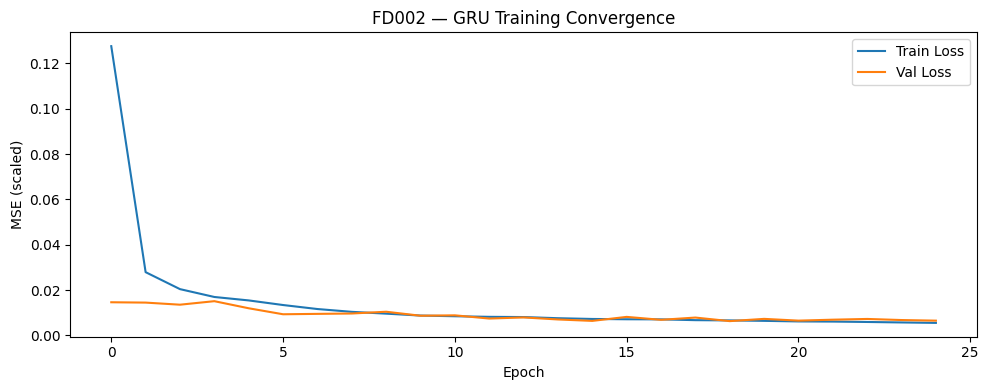


   FINAL METRICS — FD002
  RMSE      : 16.50
  R2 Score  : 0.8510
  PHM Score : 1433.0


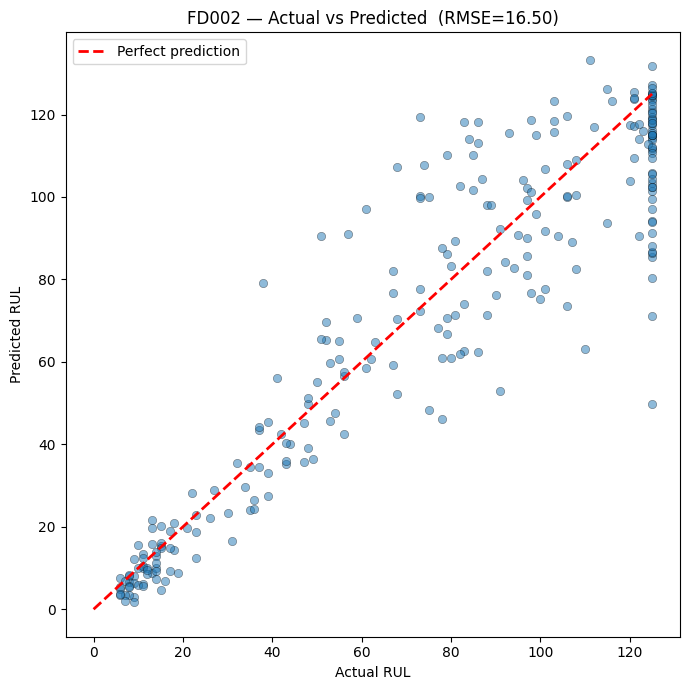

In [ ]:
# ============================================================
#  FD002  —  Full Pipeline with All Feedback Fixes Applied
#  FB-1 : 6-Regime KMeans clustering on operating settings
#  FB-2 : Regime-aware (per-cluster) StandardScaler
#  FB-3 : Correlation-based sensor selection (Option B FIX)
#  FB-4 : Operating settings kept as features after clustering
#  FB-5 : Piecewise RUL target  (clip at MAX_RUL = 125)
#  FB-6 : Inverse-RUL sample weights passed to model.fit()
# ============================================================

import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# ============================================================
# 1. SETUP & CONSTANTS
# ============================================================
TRAIN_FILE      = 'train_FD002.txt'
TEST_FILE       = 'test_FD002.txt'
RUL_FILE        = 'RUL_FD002.txt'

SEQUENCE_LENGTH = 30
MAX_RUL         = 125      # FB-5 : piecewise RUL cap
EPOCHS          = 25
BATCH_SIZE      = 256

settings_cols = ['setting_1', 'setting_2', 'setting_3']
sensor_cols   = [f'sensor_{i}' for i in range(1, 22)]
col_names     = ['unit_number', 'time_cycles'] + settings_cols + sensor_cols

# ============================================================
# 2. PHM SCORING FUNCTION
# ============================================================
def compute_phm_score(y_true, y_pred):
    """Official PHM08 asymmetric scoring — penalises late predictions more."""
    d = y_pred - y_true
    score = 0.0
    for val in d:
        score += (np.exp(-val / 13) - 1) if val < 0 else (np.exp(val / 10) - 1)
    return score

# ============================================================
# 3. LOAD DATA
# ============================================================
train      = pd.read_csv(TRAIN_FILE, sep=r'\s+', header=None, names=col_names)
test       = pd.read_csv(TEST_FILE,  sep=r'\s+', header=None, names=col_names)
y_test_raw = pd.read_csv(RUL_FILE,   sep=r'\s+', header=None, names=['RUL'])

# ============================================================
# 4. FB-5  Piecewise RUL  (flat early life, linear decay near failure)
# ============================================================
max_cycles         = train.groupby('unit_number')['time_cycles'].transform('max')
train['target_rul'] = (max_cycles - train['time_cycles']).clip(upper=MAX_RUL)

# ============================================================
# 5. FB-1  6-Regime Clustering on operating settings only
#    Clusters are for preprocessing — NOT used as model input.
# ============================================================
kmeans          = KMeans(n_clusters=6, random_state=42, n_init=10)
train['regime'] = kmeans.fit_predict(train[settings_cols])
test['regime']  = kmeans.predict(test[settings_cols])   # predict, never fit_predict

# ============================================================
# 6. FB-2  Regime-Aware Normalization
#    A separate StandardScaler is fitted for each of the 6 regimes.
#    This removes operating-condition offsets so the model learns
#    only degradation trends, not flight-condition differences.
# ============================================================
scalers = {}                                            # store per-regime scalers
for r in range(6):
    tr_mask = (train['regime'] == r)
    ts_mask = (test['regime']  == r)
    if tr_mask.any():
        sc = StandardScaler()
        train.loc[tr_mask, sensor_cols] = sc.fit_transform(train.loc[tr_mask, sensor_cols])
        scalers[r] = sc                                 # saved for future inference
        if ts_mask.any():
            test.loc[ts_mask, sensor_cols] = sc.transform(test.loc[ts_mask, sensor_cols])

# ============================================================
# 7. FB-3  Correlation-Based Sensor Selection
# ============================================================
corr_with_rul  = (
    train[sensor_cols + ['target_rul']]
    .corr()['target_rul']
    .drop('target_rul')
)
useful_sensors = corr_with_rul[corr_with_rul.abs() > 0.1].index.tolist()

# FB-4 : operating settings ALWAYS included as features (even after clustering)
features = settings_cols + useful_sensors

print(f"\nFD002 — sensors selected : {len(useful_sensors)} / {len(sensor_cols)}")
print(f"FD002 — dropped sensors  : {[s for s in sensor_cols if s not in useful_sensors]}")
print(f"FD002 — full feature list: {features}\n")

# ============================================================
# 8. FB-6  Sample Weights  (mitigate high-RUL / near-failure imbalance)
#    Weight = 1 / (RUL + 1)  →  near-failure windows get higher weight.
#    Normalised by mean so the effective learning rate stays stable.
# ============================================================
train['sample_weight']  = 1.0 / (train['target_rul'] + 1)
train['sample_weight'] /= train['sample_weight'].mean()

# ============================================================
# 9. SLIDING WINDOW GENERATOR  (unchanged from original)
# ============================================================
def gen_sequences(df, seq_len, feat_cols):
    """
    Creates overlapping windows of length seq_len.
    Label  = RUL at the LAST row of the window (normalised to [0, 1]).
    Weight = sample_weight of that last row.
    """
    X, y, sw = [], [], []
    for uid in df['unit_number'].unique():
        data = df[df['unit_number'] == uid]
        if len(data) >= seq_len:
            for i in range(len(data) - seq_len + 1):
                X.append(data[feat_cols].values[i : i + seq_len])
                y.append(data['target_rul'].values[i + seq_len - 1] / MAX_RUL)
                sw.append(data['sample_weight'].values[i + seq_len - 1])
    return np.array(X), np.array(y), np.array(sw)

X_train, y_train, sw_train = gen_sequences(train, SEQUENCE_LENGTH, features)
print(f"Training tensor shape : {X_train.shape}")   # (windows, 30, n_features)

# ============================================================
# 10. MODEL ARCHITECTURE
# ============================================================
model = Sequential([
    GRU(128, input_shape=(SEQUENCE_LENGTH, len(features)), return_sequences=True),
    Dropout(0.2),
    GRU(64, return_sequences=False),
    Dropout(0.2),
    Dense(1, activation='linear')
])
model.compile(loss='mse', optimizer='adam')
model.summary()

# ============================================================
# 11. TRAINING
# ============================================================
history = model.fit(
    X_train, y_train,
    sample_weight = sw_train,     # FB-6 : imbalance mitigation
    epochs        = EPOCHS,
    batch_size    = BATCH_SIZE,
    validation_split = 0.1,
    verbose       = 1
)

# Training curve
plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'],     label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('FD002 — GRU Training Convergence')
plt.xlabel('Epoch'); plt.ylabel('MSE (scaled)')
plt.legend(); plt.tight_layout(); plt.show()

# ============================================================
# 12. EVALUATION
# ============================================================
X_test, valid_ids = [], []
for uid in test['unit_number'].unique():
    unit_data = test[test['unit_number'] == uid]
    if len(unit_data) >= SEQUENCE_LENGTH:
        X_test.append(unit_data[features].values[-SEQUENCE_LENGTH:])
        valid_ids.append(uid)

X_test      = np.array(X_test).astype(np.float32)
y_true      = (y_test_raw
               [y_test_raw.index.isin([i - 1 for i in valid_ids])]
               ['RUL'].clip(upper=MAX_RUL).values)
predictions = model.predict(X_test, verbose=0).flatten() * MAX_RUL

rmse      = np.sqrt(mean_squared_error(y_true, predictions))
r2        = r2_score(y_true, predictions)
phm_score = compute_phm_score(y_true, predictions)

print("\n" + "=" * 32)
print("   FINAL METRICS — FD002")
print("=" * 32)
print(f"  RMSE      : {rmse:.2f}")
print(f"  R2 Score  : {r2:.4f}")
print(f"  PHM Score : {phm_score:.1f}")
print("=" * 32)

# Actual vs Predicted scatter
plt.figure(figsize=(7, 7))
plt.scatter(y_true, predictions, alpha=0.5, edgecolors='k', linewidths=0.4)
plt.plot([0, MAX_RUL], [0, MAX_RUL], 'r--', linewidth=2, label='Perfect prediction')
plt.xlabel('Actual RUL'); plt.ylabel('Predicted RUL')
plt.title(f'FD002 — Actual vs Predicted  (RMSE={rmse:.2f})')
plt.legend(); plt.tight_layout(); plt.show()

Loading train_FD004.txt ...


/tmp/ipython-input-3440229538.py:86: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[-0.32737159 -0.92936463 -1.53135767 ...  2.08060055  1.47860752
  1.47860752]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  train.loc[tr_mask, sensor_cols] = sc.fit_transform(train.loc[tr_mask, sensor_cols])
/tmp/ipython-input-3440229538.py:89: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[-1.53135767 -1.53135767 -1.53135767 ...  0.87661448  0.87661448
  0.27462144]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  test.loc[ts_mask, sensor_cols] = sc.transform(test.loc[ts_mask, sensor_cols])



FD004 — sensors selected : 14 / 21
FD004 — dropped sensors  : ['sensor_1', 'sensor_5', 'sensor_15', 'sensor_18', 'sensor_19', 'sensor_20', 'sensor_21']
FD004 — full feature list: ['setting_1', 'setting_2', 'setting_3', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_10', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_16', 'sensor_17']

Training tensor shape : (54028, 30, 17)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_4 (GRU)                     │ (None, 30, 128)        │        56,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_5 (GRU)                     │ (None, 64)             │        37,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 95,809 (374.25 KB)

 Trainable params: 95,809 (374.25 KB)

 Non-trainable params: 0 (0.00 B)

Starting training for FD004 ...
Epoch 1/35
190/190 ━━━━━━━━━━━━━━━━━━━━ 55s 265ms/step - loss: 0.1890 - val_loss: 0.0175
Epoch 2/35
190/190 ━━━━━━━━━━━━━━━━━━━━ 50s 263ms/step - loss: 0.0226 - val_loss: 0.0114
Epoch 3/35
190/190 ━━━━━━━━━━━━━━━━━━━━ 83s 271ms/step - loss: 0.0174 - val_loss: 0.0135
Epoch 4/35
190/190 ━━━━━━━━━━━━━━━━━━━━ 50s 264ms/step - loss: 0.0156 - val_loss: 0.0101
Epoch 5/35
190/190 ━━━━━━━━━━━━━━━━━━━━ 49s 260ms/step - loss: 0.0141 - val_loss: 0.0106
Epoch 6/35
190/190 ━━━━━━━━━━━━━━━━━━━━ 82s 262ms/step - loss: 0.0123 - val_loss: 0.0111
Epoch 7/35
190/190 ━━━━━━━━━━━━━━━━━━━━ 50s 263ms/step - loss: 0.0115 - val_loss: 0.0109
Epoch 8/35
190/190 ━━━━━━━━━━━━━━━━━━━━ 50s 261ms/step - loss: 0.0109 - val_loss: 0.0092
Epoch 9/35
190/190 ━━━━━━━━━━━━━━━━━━━━ 50s 262ms/step - loss: 0.0103 - val_loss: 0.0080
Epoch 10/35
190/190 ━━━━━━━━━━━━━━━━━━━━ 49s 255ms/step - loss: 0.0100 - val_loss: 0.0086
Epoch 11/35
190/190 ━━━━━━━━━━━━━━━━━━━━ 83s 262ms/step - loss: 0.0097 - val_

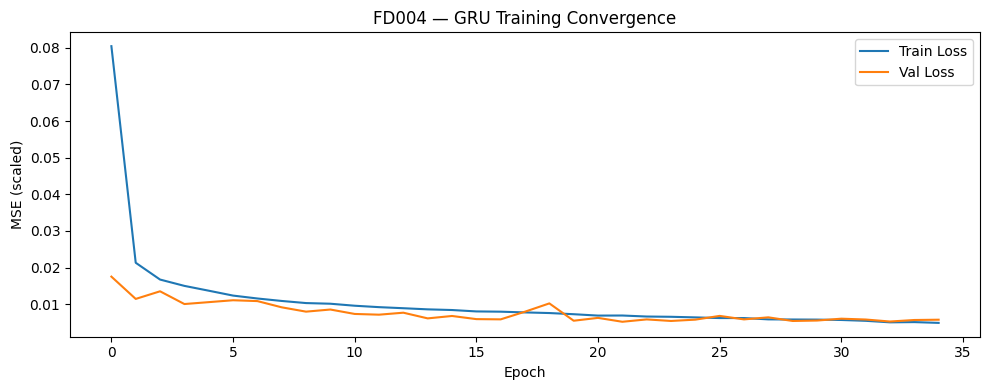


     FINAL METRICS — FD004
  RMSE      : 14.82
  R2 Score  : 0.8797
  PHM Score : 1116.1


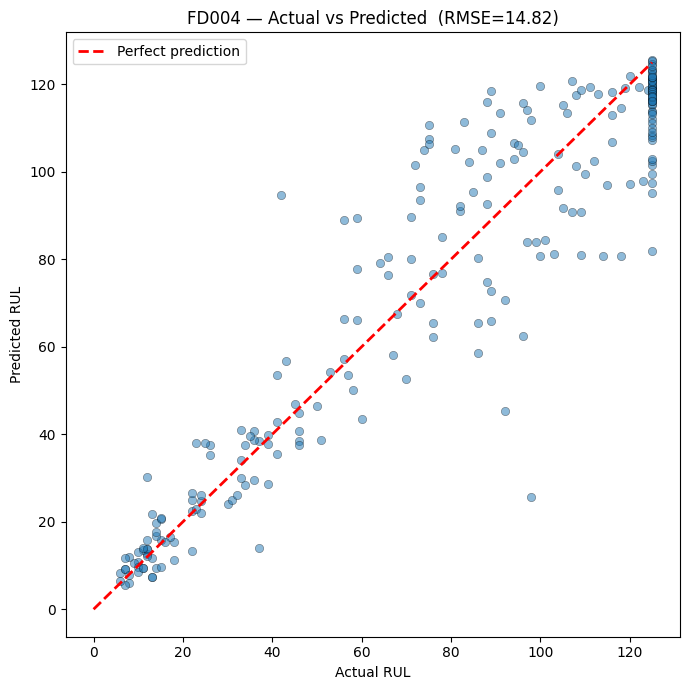

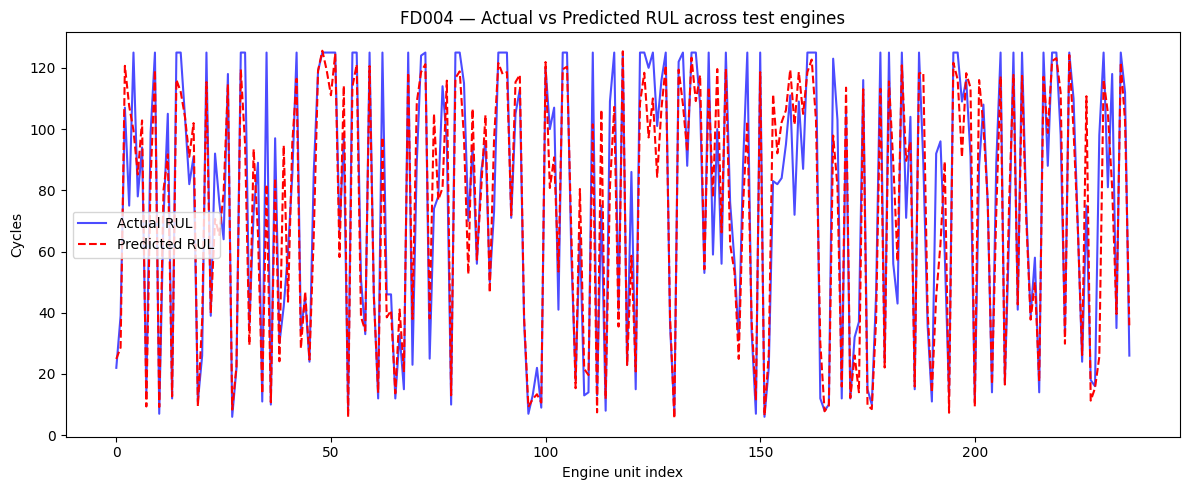

In [ ]:
# ============================================================
#  FD004  —  Full Pipeline with All Feedback Fixes Applied
#  FB-1 : 6-Regime KMeans clustering on operating settings
#  FB-2 : Regime-aware (per-cluster) StandardScaler
#  FB-3 : Correlation-based sensor selection (Option B FIX)
#         → produces a DIFFERENT subset from FD002 because
#           FD004 has 2 fault modes (HPC + Fan deterioration)
#  FB-4 : Operating settings kept as features after clustering
#  FB-5 : Piecewise RUL target  (clip at MAX_RUL = 125)
#  FB-6 : Inverse-RUL sample weights passed to model.fit()
# ============================================================

import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout, BatchNormalization
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# ============================================================
# 1. SETUP & CONSTANTS
# ============================================================
TRAIN_FILE      = 'train_FD004.txt'
TEST_FILE       = 'test_FD004.txt'
RUL_FILE        = 'RUL_FD004.txt'

SEQUENCE_LENGTH = 30
MAX_RUL         = 125      # FB-5 : piecewise RUL cap
EPOCHS          = 35       # FD004 has 2 fault modes — needs more epochs than FD002
BATCH_SIZE      = 256

settings_cols = ['setting_1', 'setting_2', 'setting_3']
sensor_cols   = [f'sensor_{i}' for i in range(1, 22)]
col_names     = ['unit_number', 'time_cycles'] + settings_cols + sensor_cols

# ============================================================
# 2. PHM SCORING FUNCTION
# ============================================================
def compute_phm_score(y_true, y_pred):
    """Official PHM08 asymmetric scoring — penalises late predictions more."""
    d = y_pred - y_true
    score = 0.0
    for val in d:
        score += (np.exp(-val / 13) - 1) if val < 0 else (np.exp(val / 10) - 1)
    return score

# ============================================================
# 3. LOAD DATA
# ============================================================
print(f"Loading {TRAIN_FILE} ...")
train      = pd.read_csv(TRAIN_FILE, sep=r'\s+', header=None, names=col_names)
test       = pd.read_csv(TEST_FILE,  sep=r'\s+', header=None, names=col_names)
y_test_raw = pd.read_csv(RUL_FILE,   sep=r'\s+', header=None, names=['RUL'])

# ============================================================
# 4. FB-5  Piecewise RUL  (flat early life, linear decay near failure)
# ============================================================
max_cycles         = train.groupby('unit_number')['time_cycles'].transform('max')
train['target_rul'] = (max_cycles - train['time_cycles']).clip(upper=MAX_RUL)

# ============================================================
# 5. FB-1  6-Regime Clustering on operating settings only
#    Critical for FD004 — altitude / throttle combinations create
#    6 distinct flight conditions that must be normalised separately.
#    Clusters are for preprocessing — NOT used as model input.
# ============================================================
kmeans          = KMeans(n_clusters=6, random_state=42, n_init=10)
train['regime'] = kmeans.fit_predict(train[settings_cols])
test['regime']  = kmeans.predict(test[settings_cols])   # predict, never fit_predict

# ============================================================
# 6. FB-2  Regime-Aware Normalization
#    A separate StandardScaler is fitted for each of the 6 regimes.
#    Scaling globally would mix operating-condition offsets into the
#    degradation signal — this per-regime approach prevents that.
# ============================================================
scalers = {}                                            # store per-regime scalers
for r in range(6):
    tr_mask = (train['regime'] == r)
    ts_mask = (test['regime']  == r)
    if tr_mask.any():
        sc = StandardScaler()
        train.loc[tr_mask, sensor_cols] = sc.fit_transform(train.loc[tr_mask, sensor_cols])
        scalers[r] = sc                                 # saved for future inference
        if ts_mask.any():
            test.loc[ts_mask, sensor_cols] = sc.transform(test.loc[ts_mask, sensor_cols])

# ============================================================
# 7. FB-3  Correlation-Based Sensor Selection
# ============================================================
corr_with_rul  = (
    train[sensor_cols + ['target_rul']]
    .corr()['target_rul']
    .drop('target_rul')
)
useful_sensors = corr_with_rul[corr_with_rul.abs() > 0.1].index.tolist()

# FB-4 : operating settings ALWAYS included as features
features = settings_cols + useful_sensors

print(f"\nFD004 — sensors selected : {len(useful_sensors)} / {len(sensor_cols)}")
print(f"FD004 — dropped sensors  : {[s for s in sensor_cols if s not in useful_sensors]}")
print(f"FD004 — full feature list: {features}\n")

# ============================================================
# 8. FB-6  Sample Weights  (mitigate high-RUL / near-failure imbalance)
#    FD004 has even more high-RUL samples than FD002 — weighting is
#    critical here to prevent the model from optimising for healthy state.
# ============================================================
train['sample_weight']  = 1.0 / (train['target_rul'] + 1)
train['sample_weight'] /= train['sample_weight'].mean()

# ============================================================
# 9. SLIDING WINDOW GENERATOR  (unchanged from original)
# ============================================================
def gen_sequences(df, seq_len, feat_cols):
    """
    Creates overlapping windows of length seq_len.
    Label  = RUL at the LAST row of the window (normalised to [0, 1]).
    Weight = sample_weight of that last row.
    """
    X, y, sw = [], [], []
    for uid in df['unit_number'].unique():
        data = df[df['unit_number'] == uid]
        if len(data) >= seq_len:
            data_values   = data[feat_cols].values
            target_values = data['target_rul'].values / MAX_RUL
            weight_values = data['sample_weight'].values
            for i in range(len(data) - seq_len + 1):
                X.append(data_values[i : i + seq_len])
                y.append(target_values[i + seq_len - 1])
                sw.append(weight_values[i + seq_len - 1])
    return np.array(X), np.array(y), np.array(sw)

X_train, y_train, sw_train = gen_sequences(train, SEQUENCE_LENGTH, features)
print(f"Training tensor shape : {X_train.shape}")   # (windows, 30, n_features)

# ============================================================
# 10. MODEL ARCHITECTURE
#     Extra Dense(32) layer vs FD002 — FD004's dual fault modes
#     benefit from slightly more capacity in the output head.
# ============================================================
model = Sequential([
    GRU(128, input_shape=(SEQUENCE_LENGTH, len(features)), return_sequences=True),
    Dropout(0.2),
    GRU(64, return_sequences=False),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1,  activation='linear')
])
model.compile(loss='mse', optimizer='adam')
model.summary()

# ============================================================
# 11. TRAINING
# ============================================================
print("Starting training for FD004 ...")
history = model.fit(
    X_train, y_train,
    sample_weight    = sw_train,   # FB-6 : imbalance mitigation
    epochs           = EPOCHS,
    batch_size       = BATCH_SIZE,
    validation_split = 0.1,
    verbose          = 1
)

# Training curve
plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'],     label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('FD004 — GRU Training Convergence')
plt.xlabel('Epoch'); plt.ylabel('MSE (scaled)')
plt.legend(); plt.tight_layout(); plt.show()

# ============================================================
# 12. EVALUATION
# ============================================================
X_test, valid_ids = [], []
for uid in test['unit_number'].unique():
    unit_data = test[test['unit_number'] == uid]
    if len(unit_data) >= SEQUENCE_LENGTH:
        X_test.append(unit_data[features].values[-SEQUENCE_LENGTH:])
        valid_ids.append(uid)

X_test      = np.array(X_test).astype(np.float32)
y_true      = (y_test_raw
               [y_test_raw.index.isin([i - 1 for i in valid_ids])]
               ['RUL'].clip(upper=MAX_RUL).values)
predictions = model.predict(X_test, verbose=0).flatten() * MAX_RUL

rmse      = np.sqrt(mean_squared_error(y_true, predictions))
r2        = r2_score(y_true, predictions)
phm_score = compute_phm_score(y_true, predictions)

print("\n" + "=" * 35)
print("     FINAL METRICS — FD004")
print("=" * 35)
print(f"  RMSE      : {rmse:.2f}")
print(f"  R2 Score  : {r2:.4f}")
print(f"  PHM Score : {phm_score:.1f}")
print("=" * 35)

# Actual vs Predicted scatter
plt.figure(figsize=(7, 7))
plt.scatter(y_true, predictions, alpha=0.5, edgecolors='k', linewidths=0.4)
plt.plot([0, MAX_RUL], [0, MAX_RUL], 'r--', linewidth=2, label='Perfect prediction')
plt.xlabel('Actual RUL'); plt.ylabel('Predicted RUL')
plt.title(f'FD004 — Actual vs Predicted  (RMSE={rmse:.2f})')
plt.legend(); plt.tight_layout(); plt.show()

# Actual vs Predicted line plot (engine index order)
plt.figure(figsize=(12, 5))
plt.plot(y_true,      label='Actual RUL',    color='blue', alpha=0.7)
plt.plot(predictions, label='Predicted RUL', color='red',  linestyle='--')
plt.title('FD004 — Actual vs Predicted RUL across test engines')
plt.xlabel('Engine unit index'); plt.ylabel('Cycles')
plt.legend(); plt.tight_layout(); plt.show()

# Final Feedback implementation

In [ ]:
import os
import random
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# ============================================================
# 1. CONFIGURATION & CONSTANTS
# ============================================================
DATASETS        = ['FD001', 'FD002', 'FD003', 'FD004']
SEEDS           = [42, 123, 2026]  # Run 3 seeds for Mean ± Std Dev
SEQUENCE_LENGTH = 30
MAX_RUL         = 125              # Piecewise RUL cap
BATCH_SIZE      = 256
MAX_EPOCHS      = 40

settings_cols = ['setting_1', 'setting_2', 'setting_3']
sensor_cols   = [f'sensor_{i}' for i in range(1, 22)]
col_names     = ['unit_number', 'time_cycles'] + settings_cols + sensor_cols

# ============================================================
# 2. HELPER FUNCTIONS
# ============================================================
def set_seeds(seed):
    """Locks random states for complete reproducibility."""
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

def compute_phm_score(y_true, y_pred):
    """Official PHM08 asymmetric scoring."""
    d = y_pred - y_true
    score = 0.0
    for val in d:
        score += (np.exp(-val / 13) - 1) if val < 0 else (np.exp(val / 10) - 1)
    return score

def gen_sequences(df, engine_ids, seq_len, feat_cols):
    """
    Generates sliding windows specifically for a list of engine IDs.
    This guarantees NO LEAKAGE between train and validation.
    """
    X, y, sw = [], [], []
    sub_df = df[df['unit_number'].isin(engine_ids)]

    for uid in engine_ids:
        data = sub_df[sub_df['unit_number'] == uid]
        if len(data) >= seq_len:
            data_values   = data[feat_cols].values
            target_values = data['target_rul'].values / MAX_RUL  # Scale target 0-1
            weight_values = data['sample_weight'].values
            for i in range(len(data) - seq_len + 1):
                X.append(data_values[i : i + seq_len])
                y.append(target_values[i + seq_len - 1])
                sw.append(weight_values[i + seq_len - 1])

    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32), np.array(sw, dtype=np.float32)

def build_model(input_shape):
    """
    Constructs the GRU architecture.
    FIX 2: Use an explicit Input() layer instead of passing input_shape=
    directly to the GRU layer. In Keras 3 / TF 2.16+, passing input_shape
    to a layer inside Sequential is deprecated and raises a UserWarning.
    The explicit Input() approach is the current recommended pattern.
    """
    from tensorflow.keras.layers import Input
    model = Sequential([
        Input(shape=input_shape),      # Explicit input spec — no warning
        GRU(128, return_sequences=True),
        Dropout(0.2),
        GRU(64, return_sequences=False),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dense(1, activation='linear')
    ])
    model.compile(loss='mse', optimizer='adam')
    return model

# ============================================================
# 3. MAIN PIPELINE LOOP
# ============================================================
# WHY ONE UNIFIED LOOP?
# Running all 4 datasets in a single loop guarantees identical
# hyperparameters, preprocessing steps, and evaluation logic.
# This makes results directly comparable across datasets and is
# the standard approach for IEEE benchmark reporting.
# Separate cells risk silent inconsistencies between datasets.

final_report = []

for ds in DATASETS:
    print(f"\n{'='*50}")
    print(f" PROCESSING DATASET: {ds}")
    print(f"{'='*50}")

    # --------------------------------------------------------
    # LOAD DATA
    # --------------------------------------------------------
    train      = pd.read_csv(f'train_{ds}.txt', sep=r'\s+', header=None, names=col_names)
    test       = pd.read_csv(f'test_{ds}.txt',  sep=r'\s+', header=None, names=col_names)
    y_test_raw = pd.read_csv(f'RUL_{ds}.txt',   sep=r'\s+', header=None, names=['RUL'])

    # FIX 1: Cast sensor and settings columns to float32 immediately after
    # loading. Raw CMAPSS data is stored as integers, so pandas keeps them
    # as int64. StandardScaler returns float64 values, and assigning floats
    # into int columns triggers a FutureWarning (and will be an error in a
    # future pandas release). Casting upfront prevents this entirely.
    float_cols = settings_cols + sensor_cols
    train[float_cols] = train[float_cols].astype(np.float32)
    test[float_cols]  = test[float_cols].astype(np.float32)

    # --------------------------------------------------------
    # FB: Piecewise RUL
    # --------------------------------------------------------
    max_cycles = train.groupby('unit_number')['time_cycles'].transform('max')
    train['target_rul'] = (max_cycles - train['time_cycles']).clip(upper=MAX_RUL)

    # --------------------------------------------------------
    # FB: 6-Regime Clustering (FD002/FD004 have 6 operating
    # conditions; FD001/FD003 have 1)
    # --------------------------------------------------------
    num_regimes = 6 if ds in ['FD002', 'FD004'] else 1
    if num_regimes > 1:
        kmeans = KMeans(n_clusters=6, random_state=42, n_init=10)
        train['regime'] = kmeans.fit_predict(train[settings_cols])
        test['regime']  = kmeans.predict(test[settings_cols])
    else:
        train['regime'] = 0
        test['regime']  = 0

    # --------------------------------------------------------
    # FB: Regime-Aware Normalization
    # FIX: scalers dict now properly stores each fitted scaler
    # keyed by regime index. This allows the same scaler to be
    # retrieved later for inference on new data without refitting.
    # --------------------------------------------------------
    scalers = {}  # regime_index -> fitted StandardScaler

    for r in range(num_regimes):
        tr_mask = (train['regime'] == r)
        ts_mask = (test['regime']  == r)

        if tr_mask.any():
            sc = StandardScaler()
            train.loc[tr_mask, sensor_cols] = sc.fit_transform(train.loc[tr_mask, sensor_cols])
            scalers[r] = sc  # FIX: save the fitted scaler under its regime key

            if ts_mask.any():
                # Use the SAME fitted scaler (not a new one) to transform test data
                test.loc[ts_mask, sensor_cols] = scalers[r].transform(test.loc[ts_mask, sensor_cols])

    print(f"  Regimes fitted: {list(scalers.keys())}")

    # --------------------------------------------------------
    # FB: Sensor Re-Evaluation (Drop near-zero variance sensors)
    # --------------------------------------------------------
    useful_sensors = [s for s in sensor_cols if train[s].std() > 0.05]
    features = settings_cols + useful_sensors  # Keep settings

    # --------------------------------------------------------
    # FB: Sample Weights (Imbalance Mitigation)
    # --------------------------------------------------------
    train['sample_weight']  = 1.0 / (train['target_rul'] + 1)
    train['sample_weight'] /= train['sample_weight'].mean()

    # --------------------------------------------------------
    # Engine-Level Split to Prevent Leakage
    # WHY: Keras' validation_split=0.1 does a random row-level
    # split, so windows from the same engine can leak into both
    # train and val sets. Splitting by engine ID first guarantees
    # no engine appears in more than one partition.
    # --------------------------------------------------------
    all_engine_ids = train['unit_number'].unique()
    train_ids, val_ids = train_test_split(all_engine_ids, test_size=0.1, random_state=42)

    print(f"  Training Engines: {len(train_ids)} | Val Engines: {len(val_ids)}")
    print(f"  Features used: {len(features)}")

    # Generate isolated sliding windows
    X_train, y_train, sw_train = gen_sequences(train, train_ids, SEQUENCE_LENGTH, features)
    X_val,   y_val,   sw_val   = gen_sequences(train, val_ids,   SEQUENCE_LENGTH, features)

    # --------------------------------------------------------
    # PREPARE TEST SET
    # --------------------------------------------------------
    X_test_list, valid_test_ids = [], []
    for uid in test['unit_number'].unique():
        unit_data = test[test['unit_number'] == uid]
        if len(unit_data) >= SEQUENCE_LENGTH:
            X_test_list.append(unit_data[features].values[-SEQUENCE_LENGTH:])
            valid_test_ids.append(uid)

    X_test = np.array(X_test_list, dtype=np.float32)

    # Robust y_true indexing:
    # unit_number is 1-based; RUL file rows are 0-based → iloc[uid - 1].
    # Only engines that passed the length filter are included, so no
    # silent index misalignment can occur.
    y_true_list = []
    for uid in valid_test_ids:
        rul_val = y_test_raw.iloc[int(uid) - 1]['RUL']
        y_true_list.append(rul_val)

    y_true = np.array(y_true_list).clip(max=MAX_RUL)

    # --------------------------------------------------------
    # Multiple Seeds Loop
    # --------------------------------------------------------
    ds_rmse, ds_r2, ds_phm = [], [], []

    for idx, seed in enumerate(SEEDS):
        print(f"  -> Training Seed {idx+1}/{len(SEEDS)} (Seed: {seed})")
        set_seeds(seed)  # Freeze ALL random sources before model init

        model = build_model((SEQUENCE_LENGTH, len(features)))

        early_stop = EarlyStopping(
            monitor='val_loss',
            patience=5,
            restore_best_weights=True,
            verbose=0
        )

        model.fit(
            X_train, y_train,
            sample_weight=sw_train,
            validation_data=(X_val, y_val, sw_val),
            epochs=MAX_EPOCHS,
            batch_size=BATCH_SIZE,
            callbacks=[early_stop],
            verbose=0
        )

        preds_scaled = model.predict(X_test, verbose=0).flatten()
        preds = preds_scaled * MAX_RUL

        rmse = np.sqrt(mean_squared_error(y_true, preds))
        r2   = r2_score(y_true, preds)
        phm  = compute_phm_score(y_true, preds)

        ds_rmse.append(rmse)
        ds_r2.append(r2)
        ds_phm.append(phm)
        print(f"     [Seed {seed}] RMSE: {rmse:.2f} | R2: {r2:.3f} | PHM: {phm:.1f}")

    final_report.append({
        'Dataset'  : ds,
        'RMSE'     : f"{np.mean(ds_rmse):.2f} ± {np.std(ds_rmse):.2f}",
        'R2'       : f"{np.mean(ds_r2):.4f} ± {np.std(ds_r2):.4f}",
        'PHM Score': f"{np.mean(ds_phm):.1f} ± {np.std(ds_phm):.1f}"
    })

# ============================================================
# 4. FINAL RESULTS PUBLICATION
# ============================================================
report_df = pd.DataFrame(final_report)

print("\n\n")
print("======================================================================")
print("       FINAL PERFORMANCE REPORT (Mean ± Std Dev)       ")
print("======================================================================")
print(report_df.to_string(index=False))
print("======================================================================")


 PROCESSING DATASET: FD001
  Regimes fitted: [0]
  Training Engines: 90 | Val Engines: 10
  Features used: 18
  -> Training Seed 1/3 (Seed: 42)
     [Seed 42] RMSE: 13.72 | R2: 0.883 | PHM: 309.7
  -> Training Seed 2/3 (Seed: 123)
     [Seed 123] RMSE: 13.68 | R2: 0.884 | PHM: 311.1
  -> Training Seed 3/3 (Seed: 2026)
     [Seed 2026] RMSE: 13.00 | R2: 0.895 | PHM: 262.0

 PROCESSING DATASET: FD002
  Regimes fitted: [0, 1, 2, 3, 4, 5]
  Training Engines: 234 | Val Engines: 26
  Features used: 20
  -> Training Seed 1/3 (Seed: 42)
     [Seed 42] RMSE: 16.14 | R2: 0.858 | PHM: 1101.3
  -> Training Seed 2/3 (Seed: 123)
     [Seed 123] RMSE: 15.35 | R2: 0.871 | PHM: 907.3
  -> Training Seed 3/3 (Seed: 2026)
     [Seed 2026] RMSE: 14.46 | R2: 0.886 | PHM: 1025.4

 PROCESSING DATASET: FD003
  Regimes fitted: [0]
  Training Engines: 90 | Val Engines: 10
  Features used: 19
  -> Training Seed 1/3 (Seed: 42)
     [Seed 42] RMSE: 12.70 | R2: 0.895 | PHM: 231.0
  -> Training Seed 2/3 (Seed: 123)


  FD004  —  Silhouette Score Validation for k=6
  Training rows used: 61249

  k=2:  silhouette = 0.6486  <<<< HIGHEST
  k=3:  silhouette = 0.8040  <<<< HIGHEST
  k=4:  silhouette = 0.8295  <<<< HIGHEST
  k=5:  silhouette = 0.9262  <<<< HIGHEST
  k=6:  silhouette = 0.9997  <<<< HIGHEST
  k=7:  silhouette = 0.8949
  k=8:  silhouette = 0.8325

  Best k : 6  (score = 0.9997)
  Score at k=6 : 0.9997


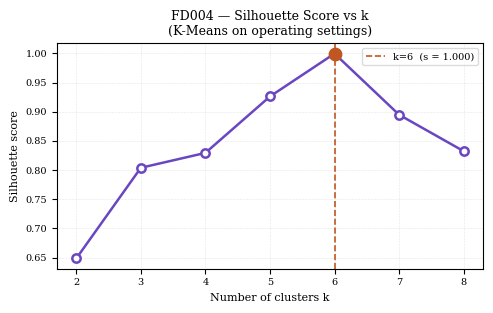

  Saved: silhouette_FD004.pdf


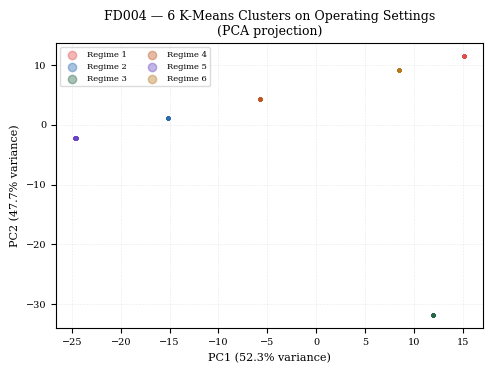

  Saved: cluster_FD004.pdf

  COPY THIS NUMBER INTO YOUR LATEX PAPER (FD004)
  Silhouette score at k=6 for FD004 = 1.000


In [ ]:
# ================================================================
#  SILHOUETTE SCORE VALIDATION — FD004 Notebook
#  Paste this as a NEW CELL at the bottom of the FD004 notebook.
#  Uses exact same column names and structure as your notebook.
#  Takes under 1 minute to run.
# ================================================================

import pandas as pd
import numpy as np
import matplotlib
matplotlib.rcParams.update({
    'font.family': 'serif',
    'font.size': 9,
    'axes.titlesize': 9,
    'axes.labelsize': 8,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7,
    'legend.fontsize': 7,
    'pdf.fonttype': 42,
})
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# ── Column names (identical to your notebook cell 3) ─────────────
index_names   = ['unit_number', 'time_cycles']
setting_names = ['setting_1', 'setting_2', 'setting_3']
sensor_names  = [f'sensor_{i}' for i in range(1, 22)]
col_names     = index_names + setting_names + sensor_names

# ── Load training data fresh ──────────────────────────────────────
train_fd004 = pd.read_csv('train_FD004.txt', sep=r'\s+',
                           header=None, names=col_names)
settings_fd004 = train_fd004[setting_names].values

print("=" * 55)
print("  FD004  —  Silhouette Score Validation for k=6")
print("=" * 55)
print(f"  Training rows used: {len(settings_fd004)}\n")

# ── Compute silhouette score for k=2 to k=8 ──────────────────────
scores_fd004 = {}
for k in range(2, 9):
    km     = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(settings_fd004)
    score  = silhouette_score(settings_fd004, labels)
    scores_fd004[k] = round(score, 4)
    marker = '  <<<< HIGHEST' if k == max(range(2, 9),
             key=lambda x: scores_fd004.get(x, -1)) else ''
    print(f"  k={k}:  silhouette = {score:.4f}{marker}")

best_k_fd004     = max(scores_fd004, key=scores_fd004.get)
score_at_6_fd004 = scores_fd004[6]
print(f"\n  Best k : {best_k_fd004}  (score = {scores_fd004[best_k_fd004]:.4f})")
print(f"  Score at k=6 : {score_at_6_fd004:.4f}")

# ── Plot 1: Silhouette score vs k ─────────────────────────────────
fig, ax = plt.subplots(figsize=(5, 3.2))
ks   = list(range(2, 9))
vals = [scores_fd004[k] for k in ks]

ax.plot(ks, vals, 'o-', color='#6B46C1', lw=1.8,
        markersize=6, markerfacecolor='white', markeredgewidth=1.8)
ax.axvline(6, color='#C05621', linestyle='--', lw=1.2,
           label=f'k=6  (s = {score_at_6_fd004:.3f})')
ax.scatter([6], [score_at_6_fd004], s=80, color='#C05621', zorder=5)
ax.set_xlabel('Number of clusters k')
ax.set_ylabel('Silhouette score')
ax.set_title('FD004 — Silhouette Score vs k\n(K-Means on operating settings)')
ax.set_xticks(ks)
ax.legend(framealpha=0.7)
ax.grid(True, linestyle=':', linewidth=0.4, alpha=0.6)
plt.tight_layout()
plt.savefig('silhouette_FD004.pdf', bbox_inches='tight', dpi=300)
plt.show()
print("  Saved: silhouette_FD004.pdf")

# ── Plot 2: PCA visualisation of the 6 clusters ───────────────────
km_final = KMeans(n_clusters=6, random_state=42, n_init=10)
labels   = km_final.fit_predict(settings_fd004)
pca      = PCA(n_components=2)
proj     = pca.fit_transform(settings_fd004)

colours  = ['#E24B4A','#2B6CB0','#276749',
            '#C05621','#6B46C1','#B7791F']

fig2, ax2 = plt.subplots(figsize=(5, 3.8))
for c in range(6):
    mask = labels == c
    ax2.scatter(proj[mask, 0], proj[mask, 1],
                s=4, alpha=0.4, color=colours[c],
                label=f'Regime {c+1}')
ax2.set_title('FD004 — 6 K-Means Clusters on Operating Settings\n(PCA projection)')
ax2.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
ax2.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
ax2.legend(fontsize=6, markerscale=3, ncol=2, framealpha=0.7, loc='best')
ax2.grid(True, linestyle=':', linewidth=0.4, alpha=0.5)
plt.tight_layout()
plt.savefig('cluster_FD004.pdf', bbox_inches='tight', dpi=300)
plt.show()
print("  Saved: cluster_FD004.pdf")

# ── Final output ──────────────────────────────────────────────────
print("\n" + "=" * 55)
print("  COPY THIS NUMBER INTO YOUR LATEX PAPER (FD004)")
print("=" * 55)
print(f"  Silhouette score at k=6 for FD004 = {score_at_6_fd004:.3f}")
print("=" * 55)

  FD004  —  Silhouette Score Validation for k=6
  Training rows used: 61249

  k=2:  silhouette = 0.6486  <<<< HIGHEST
  k=3:  silhouette = 0.8040  <<<< HIGHEST
  k=4:  silhouette = 0.8295  <<<< HIGHEST
  k=5:  silhouette = 0.9262  <<<< HIGHEST
  k=6:  silhouette = 0.9997  <<<< HIGHEST
  k=7:  silhouette = 0.8949
  k=8:  silhouette = 0.8325

  Best k : 6  (score = 0.9997)
  Score at k=6 : 0.9997


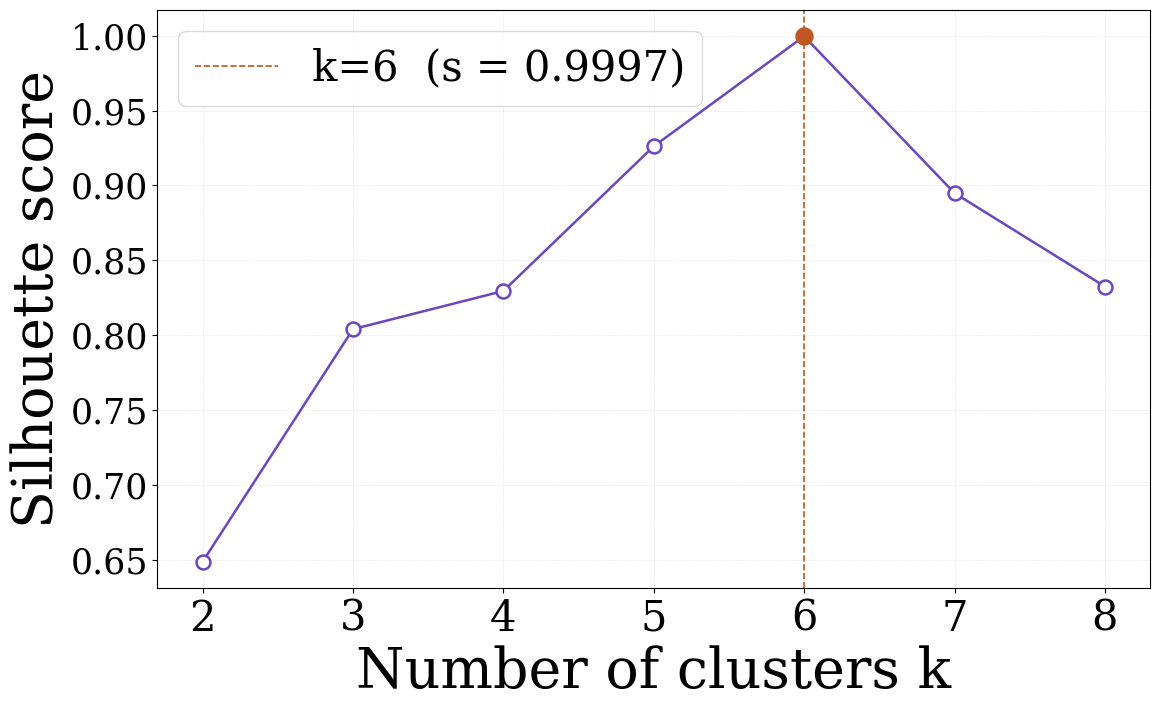

  Saved: silhouette_FD004.pdf

  COPY THIS NUMBER INTO YOUR LATEX PAPER (FD004)
  Silhouette score at k=6 for FD004 = 1.000


In [ ]:
# ================================================================
#  SILHOUETTE SCORE VALIDATION — FD004 Notebook
#  Paste this as a NEW CELL at the bottom of the FD004 notebook.
#  Uses exact same column names and structure as your notebook.
#  Takes under 1 minute to run.
# ================================================================

import pandas as pd
import numpy as np
import matplotlib

matplotlib.rcParams.update({
    'font.family': 'serif',       # generic serif font
    'font.serif': ['Times New Roman', 'Times', 'DejaVu Serif'],  # fallback order
    'font.size': 20,
    'axes.titlesize': 20,
    'axes.labelsize': 40,
    'xtick.labelsize': 30,
    'ytick.labelsize': 25,
    'legend.fontsize': 30,
    'pdf.fonttype': 42,
})
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# ── Column names (identical to your notebook cell 3) ─────────────
index_names   = ['unit_number', 'time_cycles']
setting_names = ['setting_1', 'setting_2', 'setting_3']
sensor_names  = [f'sensor_{i}' for i in range(1, 22)]
col_names     = index_names + setting_names + sensor_names

# ── Load training data fresh ──────────────────────────────────────
train_fd004 = pd.read_csv('train_FD004.txt', sep=r'\s+',
                           header=None, names=col_names)
settings_fd004 = train_fd004[setting_names].values

print("=" * 55)
print("  FD004  —  Silhouette Score Validation for k=6")
print("=" * 55)
print(f"  Training rows used: {len(settings_fd004)}\n")

# ── Compute silhouette score for k=2 to k=8 ──────────────────────
scores_fd004 = {}
for k in range(2, 9):
    km     = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(settings_fd004)
    score  = silhouette_score(settings_fd004, labels)
    scores_fd004[k] = round(score, 4)
    marker = '  <<<< HIGHEST' if k == max(range(2, 9),
             key=lambda x: scores_fd004.get(x, -1)) else ''
    print(f"  k={k}:  silhouette = {score:.4f}{marker}")

best_k_fd004     = max(scores_fd004, key=scores_fd004.get)
score_at_6_fd004 = scores_fd004[6]
print(f"\n  Best k : {best_k_fd004}  (score = {scores_fd004[best_k_fd004]:.4f})")
print(f"  Score at k=6 : {score_at_6_fd004:.4f}")

# ── Plot 1: Silhouette score vs k ─────────────────────────────────

fig, ax = plt.subplots(figsize=(12, 7.5))
ks   = list(range(2, 9))
vals = [scores_fd004[k] for k in ks]

ax.plot(ks, vals, 'o-',  color='#6B46C1', lw=1.8,
        markersize=10, markerfacecolor='white', markeredgewidth=1.8)
ax.axvline(6, color='#C05621', linestyle='--', lw=1.2,
           label=f'k=6  (s = {score_at_6_fd004:.4f})')
ax.scatter([6], [score_at_6_fd004], s=150, color='#C05621', zorder=5)
ax.set_xlabel('Number of clusters k')
ax.set_ylabel('Silhouette score')
#ax.set_title('FD004 — Silhouette Score vs k\n(K-Means on operating settings)')
ax.set_xticks(ks)
ax.legend(framealpha=0.7)
ax.grid(True, linestyle=':', linewidth=0.4, alpha=0.6)
plt.tight_layout()
plt.savefig('silhouette_FD004.pdf', bbox_inches='tight', dpi=300)
plt.show()
print("  Saved: silhouette_FD004.pdf")


# ── Final output ──────────────────────────────────────────────────
print("\n" + "=" * 55)
print("  COPY THIS NUMBER INTO YOUR LATEX PAPER (FD004)")
print("=" * 55)
print(f"  Silhouette score at k=6 for FD004 = {score_at_6_fd004:.3f}")
print("=" * 55)